In [1]:
import numpy as np
from pathlib import Path
from scipy import optimize
from iaf.plot import plot_data, add_fit
from iaf.plot.utils import plot_parameter_search_1d, plot_parameter_search_2d
from iaf.fit.metrics import calc_sse
from iaf.fit.models import linear_model
from iaf.notebook import init_style
init_style()

# Introduction to regression (curve fitting)

Some intuitions round the topic of **curve** fitting.

**Please note**: we will mostly discuss examples of curve fitting without entering the much more extensive field of regression analysis, that is well beyond the scope of this course.

## Main concepts

We have some noisy linear data and we want to fit a linear model to it. The idea is that some linear process is generating the data that we acquired or measured in some way. Because of some noise in the measurement process or some intrinsic variability in what we have measured, our measurement points will not fall exacly on a line.

The model we want to fit is `y = ax + b + e`, where `x` and `y` are our data, and `a` and `b` are the parameters of our model that we want to estimate. 

In particular:

* The parameter `a` is the slope of the line.
* The parameter `b` is the intercept of the line (i.e. the value of `y` for `x = 0`).
* The term `e` accounts for deviations between the linear model and the (noisy) data. If the data is a perfect line with no noise at all, `a` and `b` will fit the data perfectly with no deviation, and `e` will be zero. In general, the goal of model fitting is to find the curve that passes as close to all `(x, y)` pairs as possible thus minimizing the value of the residual `e`.

We will try to estimate the values of `a` and `b` in a series of attempts of increasing complexity. We will create the data to be fit by specifying several arguments as explained below.

# Part 1 - Curve fitting intuitions

## Create some data to work with

In this first part, we will use the following parameters to create the data to work with. In the real world, we usually **do not know** the parameters of the underlying model that creates the data we acquire. To gather some intuitions about model fitting, we will temporarily achieve super powers and create the data in a completely deterministic way.

In [2]:
a_real      = 3    # Real slope of the line.
b_real      = 10   # Real intercept of the line.
noise_level = 1.0  # Standard deviation of the noise around the line to mimick noisy measurements.

In [3]:
# Fix the seed of the random number generator
rng = np.random.RandomState(1)

In [4]:
# Our raw data
x = np.linspace(start=-10.0, stop=10.0, num=101)
y = a_real * x + b_real + noise_level * rng.randn(len(x))

We will use the `plot_data()` function quite a bit. Let's have a look at how we can use it.

In [5]:
# Uncomment the following to get the help
# ?plot_data

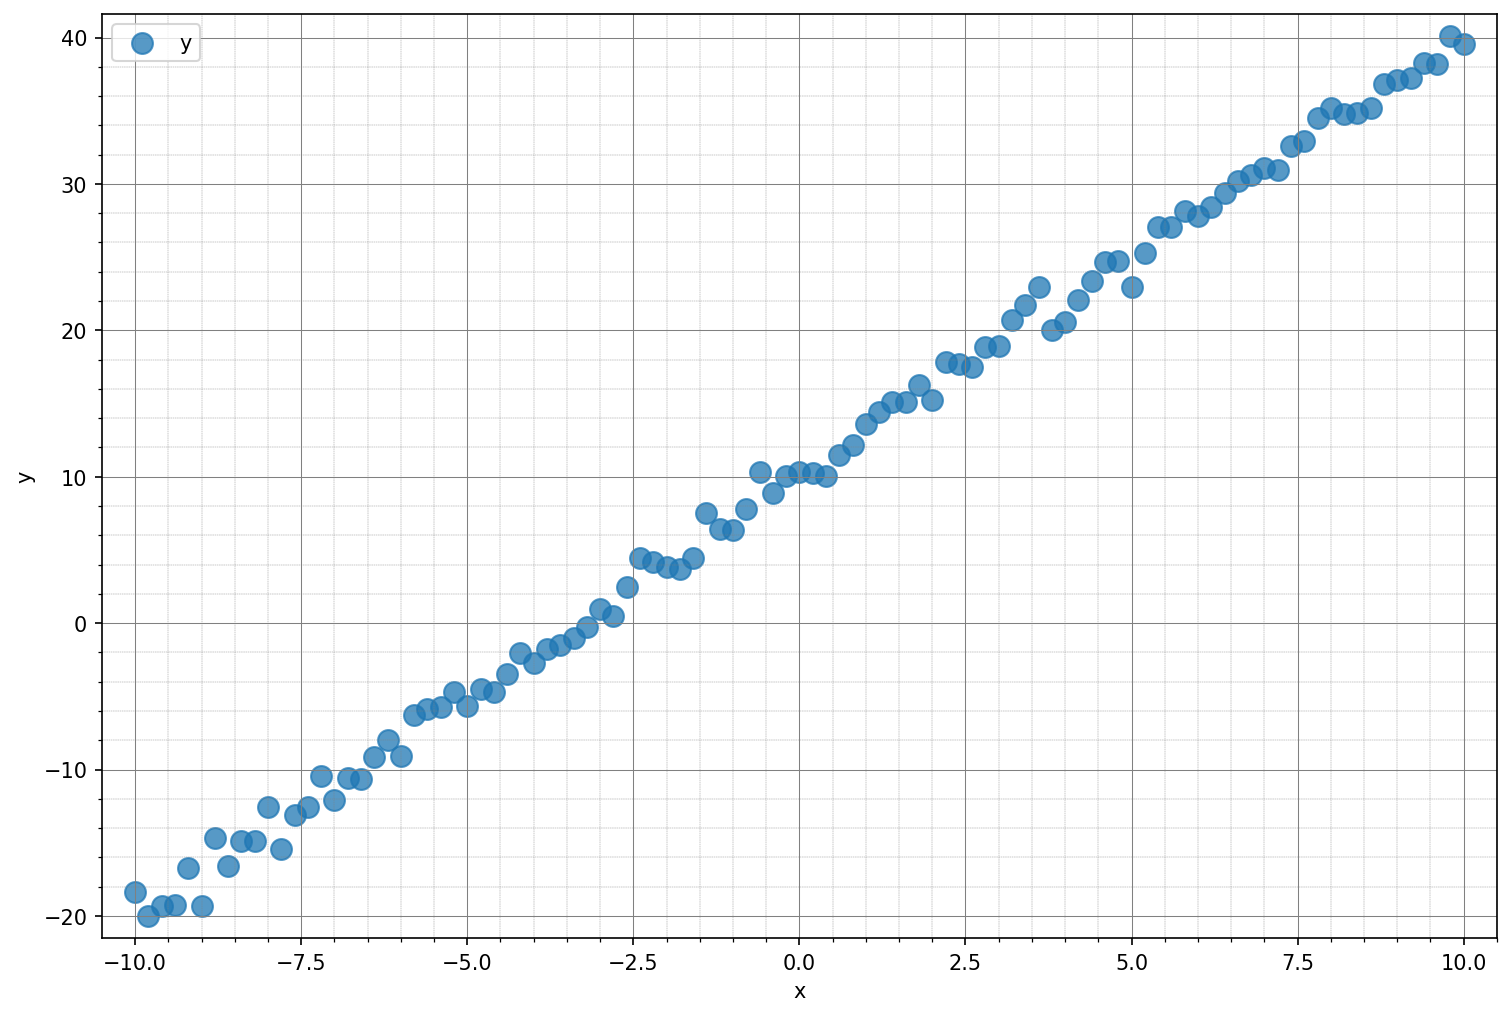

In [6]:
# Plot the data
_ = plot_data(x, y)

## Naïve fits

In the following, we will use the model function `y = a * x + b`, where `a` is the slope of the line and `b` is its intercept. We can define it as:

In [7]:
def linear_model(x, a, b):
    """Our linear model y = a * x + b."""
    y_hat = a * x + b
    return y_hat

We will be using it everywhere we need to calculate the values of the data points `y` from `x` and the (current) values of the slope `a` and the intercept `b`.

One way to assess how good a fit is to the underlying data, is to calculate the total `distance` of the predicted values from the original ones. One common way of doing this is by calculating the **sum
of the squared differences** between the data points `y` and the predicted values `y_hat`.

For this, we will define and use the function:

In [8]:
def calc_sse(y, y_hat):
    """Calculate the Sum of Squared Errors between prediction y_hat and data y."""
    sse = np.sum(np.power(y_hat - y, 2))
    return sse

### First naïve fit

"Fit" a line with slope `a = 1.5` and intercept `b = 0`.

In [9]:
a = 1.5
b = 0.0

Our model function is `y = a * x + b`, where `a` is the slope and `b` is the intercept of the line.

In [10]:
y_hat = linear_model(x, a, b)
y_hat

array([-15. , -14.7, -14.4, -14.1, -13.8, -13.5, -13.2, -12.9, -12.6,
       -12.3, -12. , -11.7, -11.4, -11.1, -10.8, -10.5, -10.2,  -9.9,
        -9.6,  -9.3,  -9. ,  -8.7,  -8.4,  -8.1,  -7.8,  -7.5,  -7.2,
        -6.9,  -6.6,  -6.3,  -6. ,  -5.7,  -5.4,  -5.1,  -4.8,  -4.5,
        -4.2,  -3.9,  -3.6,  -3.3,  -3. ,  -2.7,  -2.4,  -2.1,  -1.8,
        -1.5,  -1.2,  -0.9,  -0.6,  -0.3,   0. ,   0.3,   0.6,   0.9,
         1.2,   1.5,   1.8,   2.1,   2.4,   2.7,   3. ,   3.3,   3.6,
         3.9,   4.2,   4.5,   4.8,   5.1,   5.4,   5.7,   6. ,   6.3,
         6.6,   6.9,   7.2,   7.5,   7.8,   8.1,   8.4,   8.7,   9. ,
         9.3,   9.6,   9.9,  10.2,  10.5,  10.8,  11.1,  11.4,  11.7,
        12. ,  12.3,  12.6,  12.9,  13.2,  13.5,  13.8,  14.1,  14.4,
        14.7,  15. ])

We can now calculate the SSE:

In [11]:
sse = calc_sse(y, y_hat)
sse

18169.485449511147

Now plot the predicted `y_hat` and display a summary of the fit.

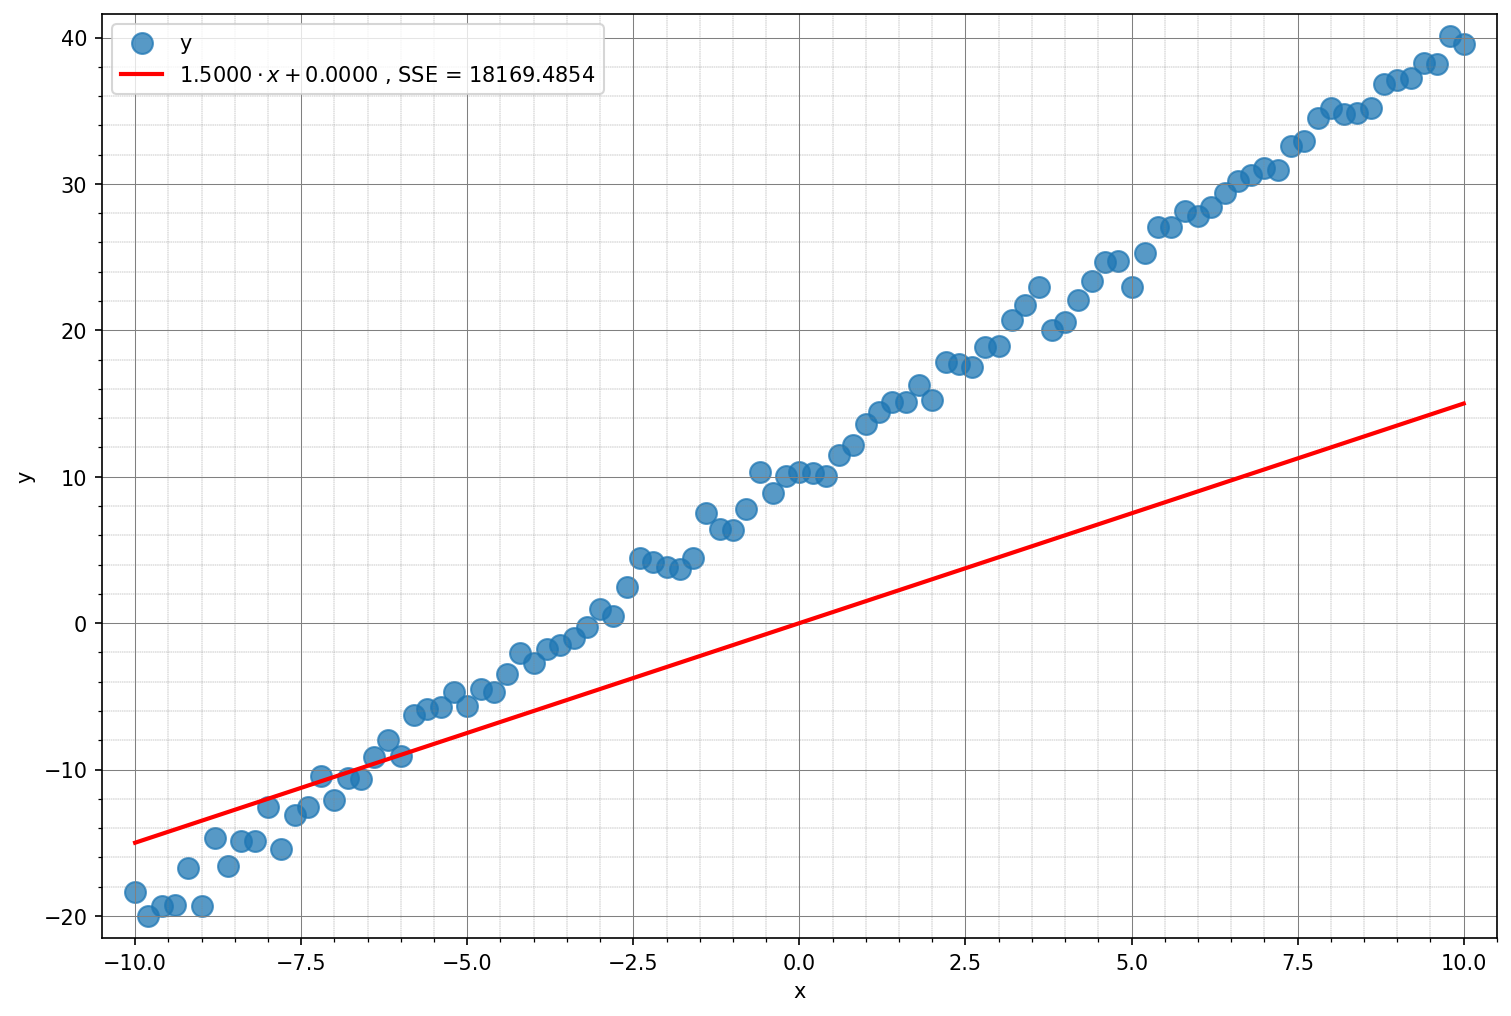

In [12]:
_ = plot_data(x, y, y_hat=y_hat, a=a, b=b, sse=sse)

## Second naïve fit

"Fit" a line with slope `a = -6` and intercept `b = 0`.

In [13]:
a = -6.0
b = 0.0

Calculate `y_hat` with the new parameters.

In [14]:
y_hat = linear_model(x, a, b)

Calculate the SSE.

In [15]:
sse = calc_sse(y, y_hat)
sse

289356.2115105961

Again, plot the predicted `y_hat` and display a summary of the fit.

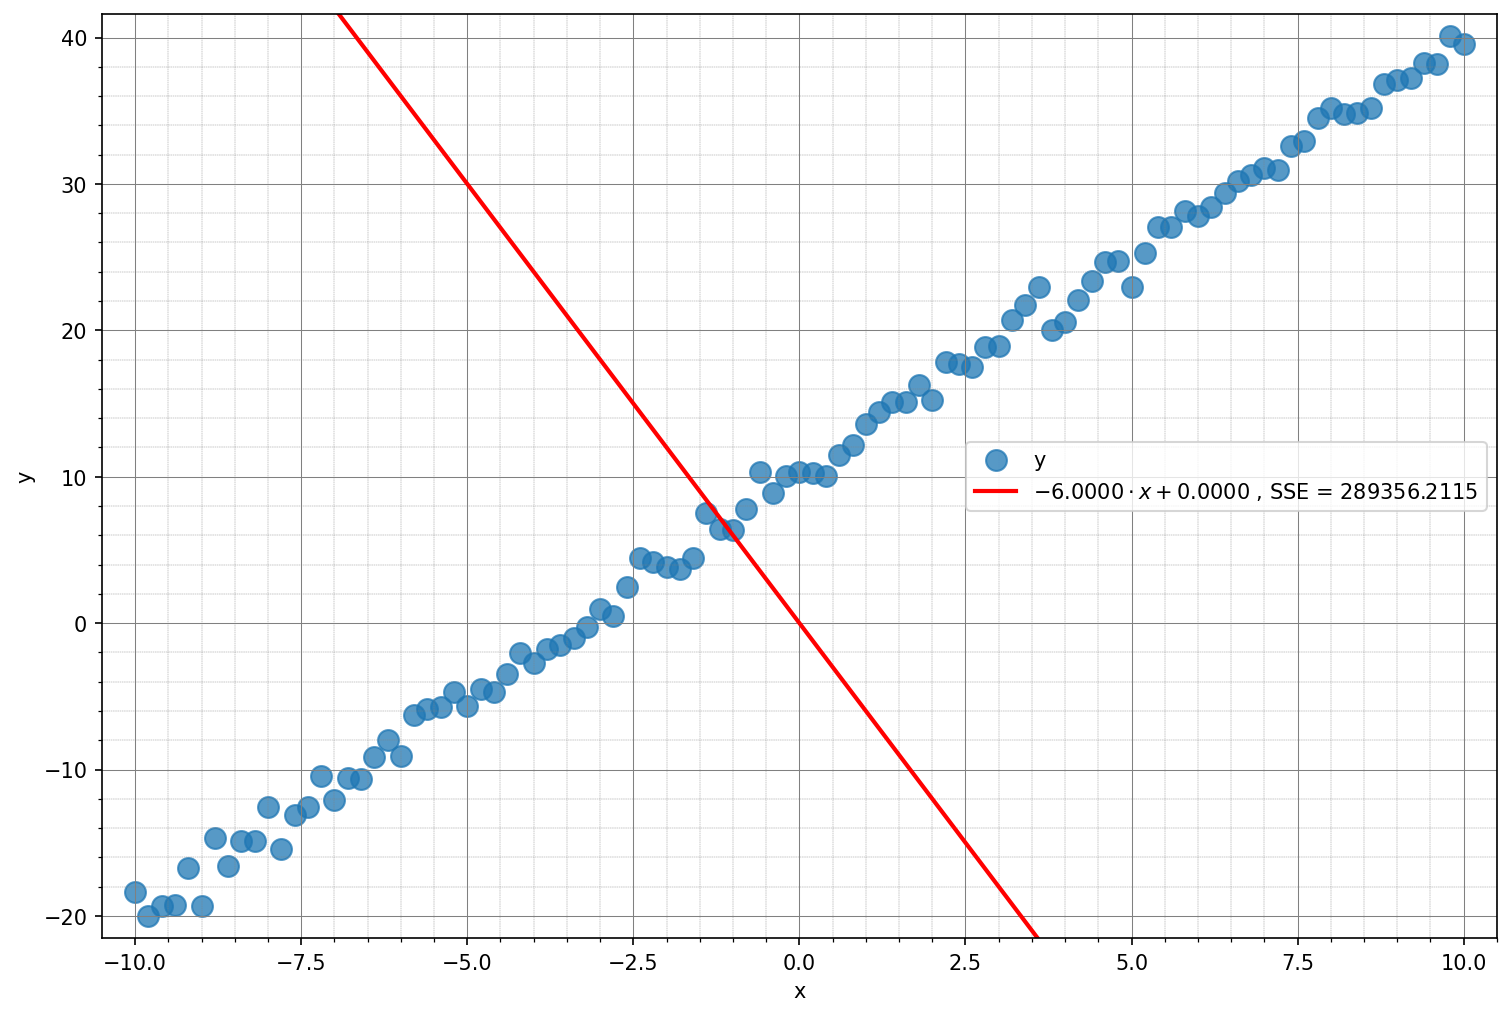

In [16]:
_ = plot_data(x, y, y_hat=y_hat, a=a, b=b, sse=sse)

## Third naïve fit

"Fit" a line with slope `a = 3` and intercept `b = 5`.

In [17]:
a = 3.0
b = 5.0

Calculate `y_hat` with the new parameters.

In [18]:
y_hat = linear_model(x, a, b)

Calculate the SSE.

In [19]:
sse = calc_sse(y, y_hat)
sse

2660.028670866315

Again, plot the predicted `y_hat` and display a summary of the fit.

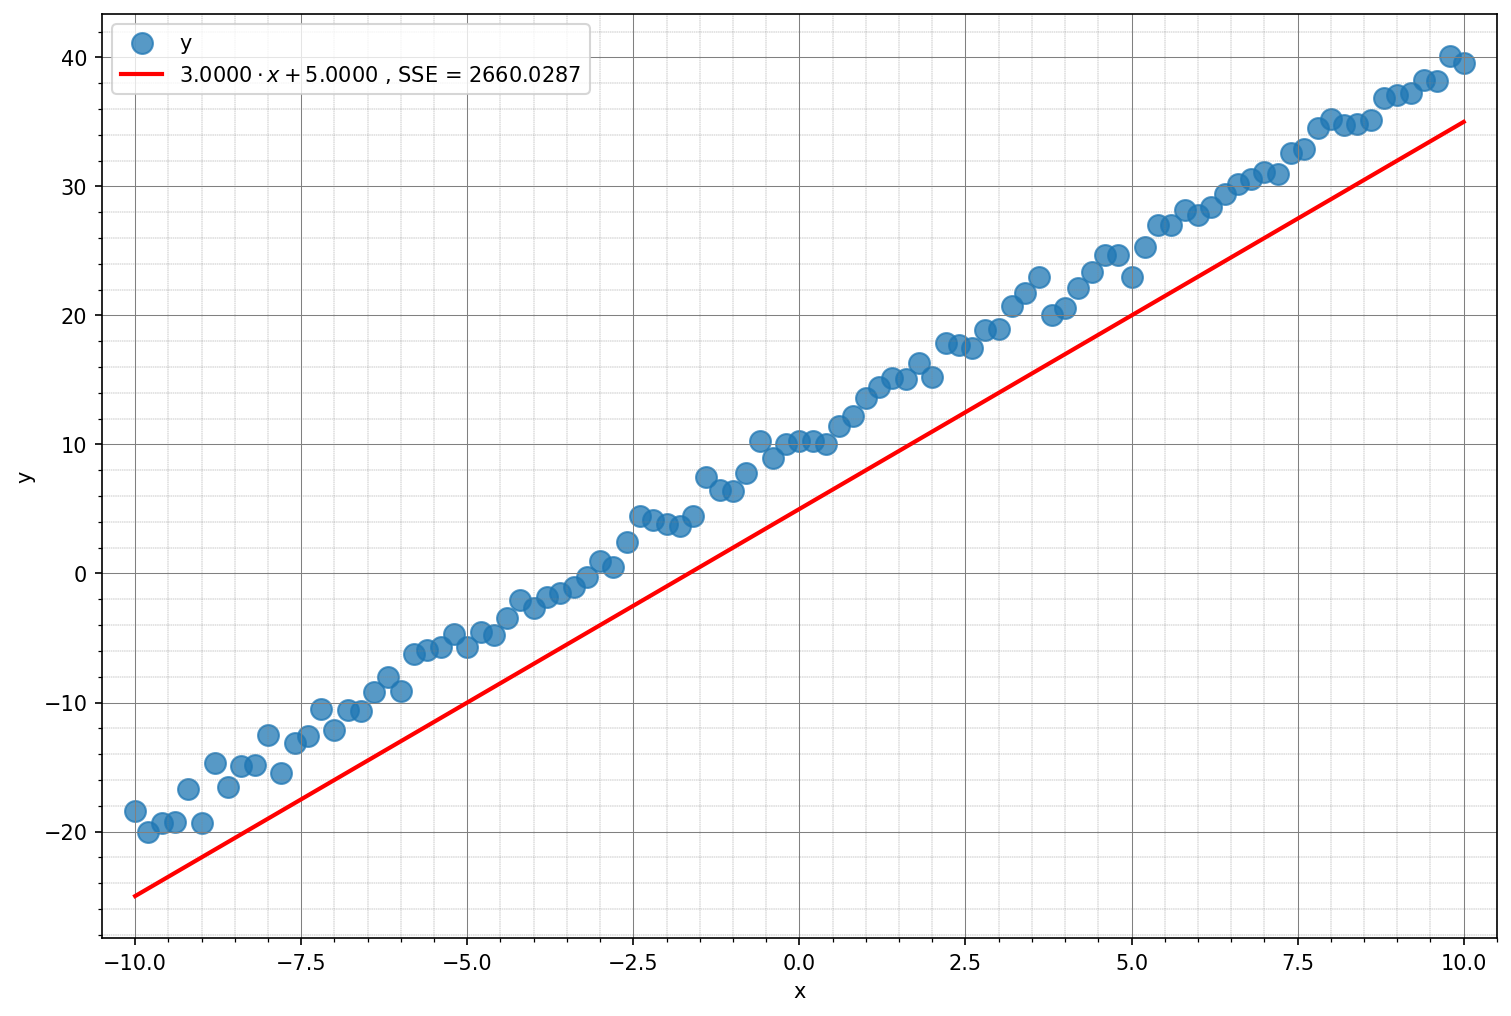

In [20]:
_ = plot_data(x, y, y_hat=y_hat, a=a, b=b, sse=sse, lim_y=(None, None))

### Fourth naive fit

"Fit" a line with correct slope and intercept.

In [21]:
a = 3.0
b = 10.0

Calculate `y_hat` with the new parameters.

In [22]:
y_hat = linear_model(x, a, b)

Calculate the SSE.

In [23]:
sse = calc_sse(y, y_hat)
sse

78.91710443847684

For the last time, plot the predicted `y_hat` and display a summary of the fit.

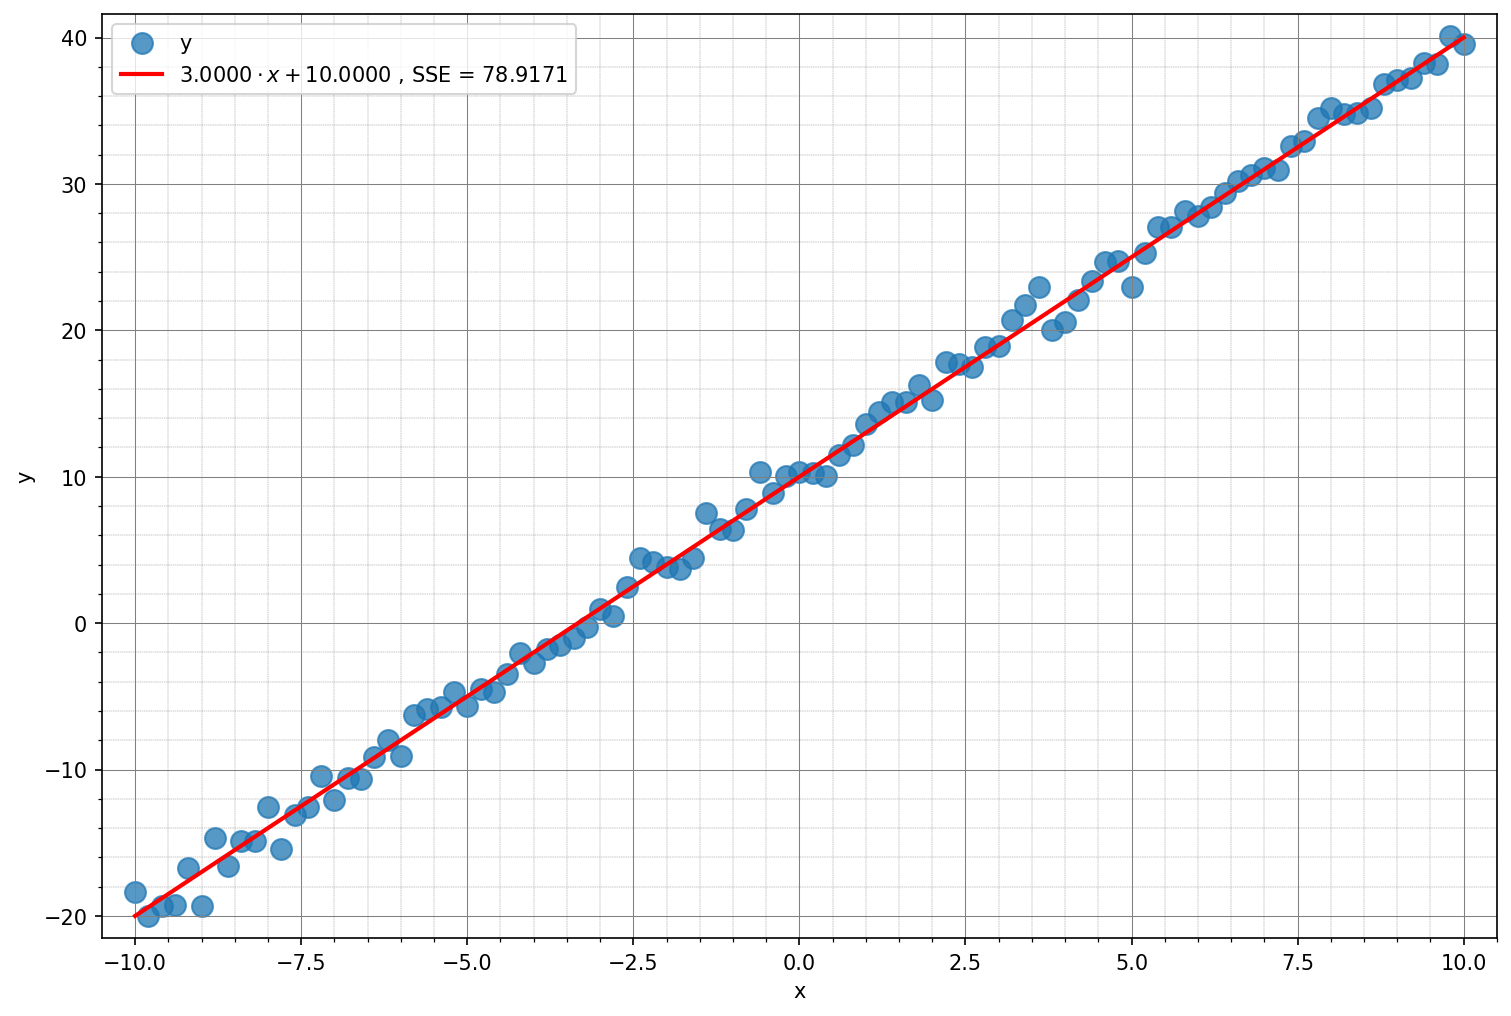

In [24]:
_ = plot_data(x, y, y_hat=y_hat, a=a, b=b, sse=sse)

## Search for the optimal line

Instead of guessing, we want to **search for** the line (i.e. the parameters `a` and `b`) that gives us the smallest possible SSE (sum of squared errors) between each value `y[i]` in the data and the predicted one `y_hat[i]`.

### Slopes only

First we ignore the intercept and only search for the slope `a` with the smallest SSE. We can use the same model as before, we just fix `b = 0`.

Let's search over a range of slope values.

In [25]:
slopes = np.linspace(start=a_real - 25, stop=a_real + 25, num=51)

We prepare a vector `SSEs` to store all values of SSE for each of the slopes.

In [26]:
SSEs = np.zeros(len(slopes))

And now we test them all.

In [27]:
for i, a in enumerate(slopes):
    y_hat = linear_model(x, a, 0)
    SSEs[i] = calc_sse(y, y_hat)

Let's plot the result of our parameter scan.

In [28]:
# Let's find the best SSE and the corresponding best slope a
SSEs = np.asarray(SSEs)
SSE_best = SSEs.min()
a_best = slopes[np.argmin(SSEs)]
a_best

3.0

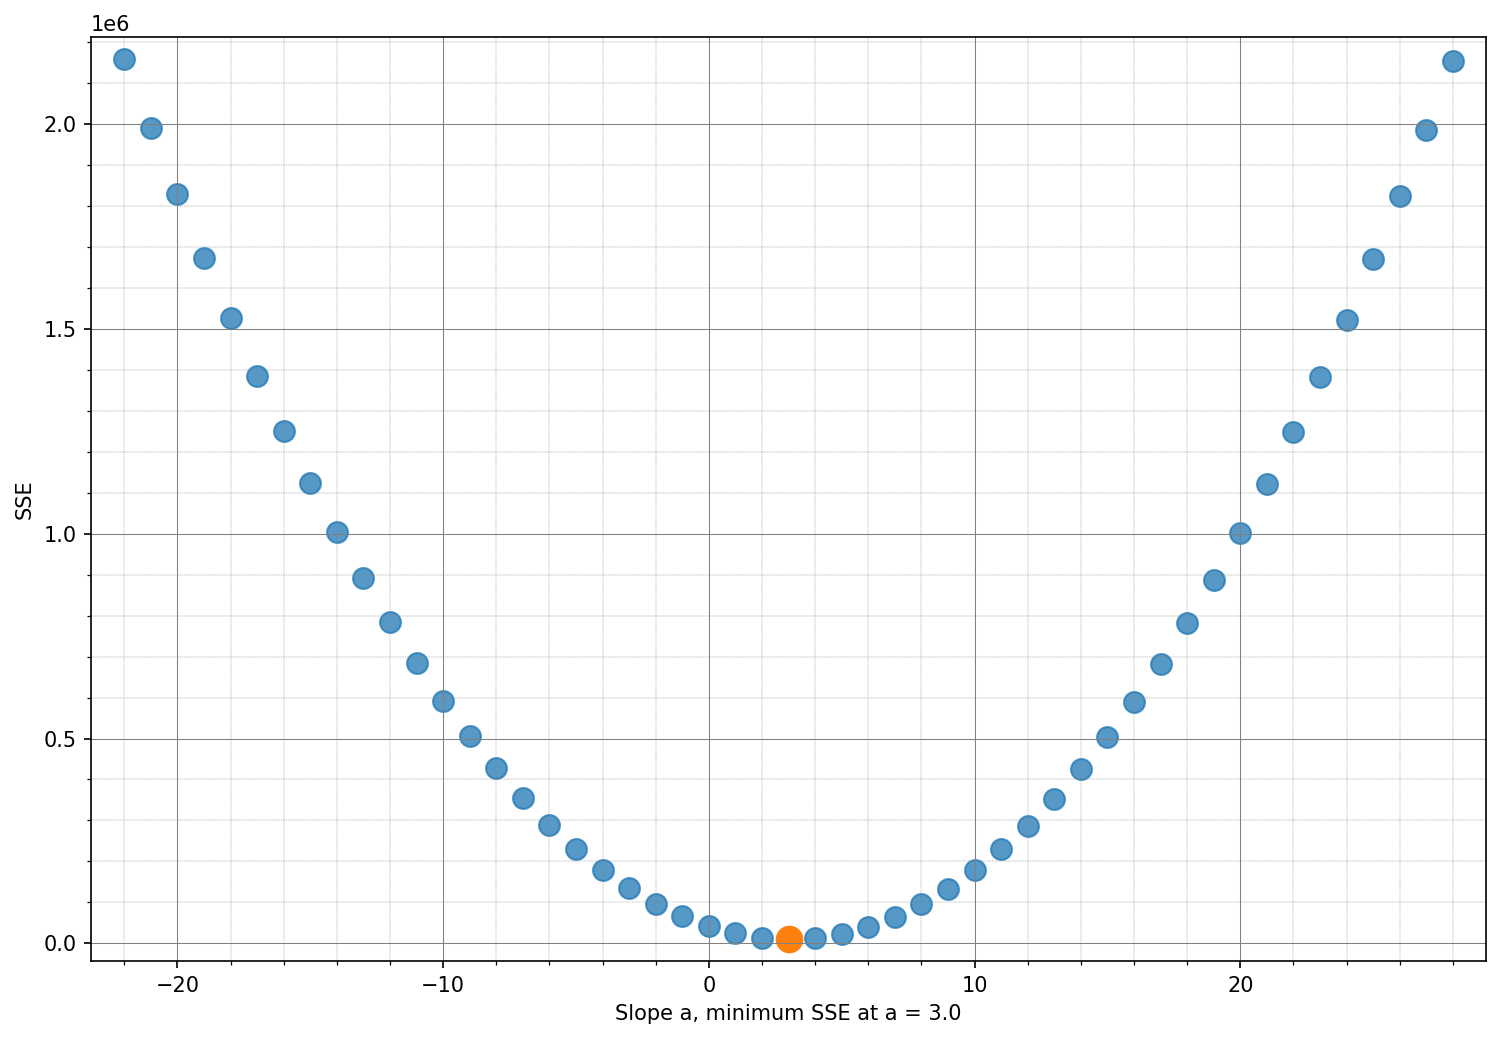

In [29]:
plot_parameter_search_1d(slopes, SSEs, a_best, SSE_best, f"Slope a, minimum SSE at a = {a_best}")

Let's plot our model.

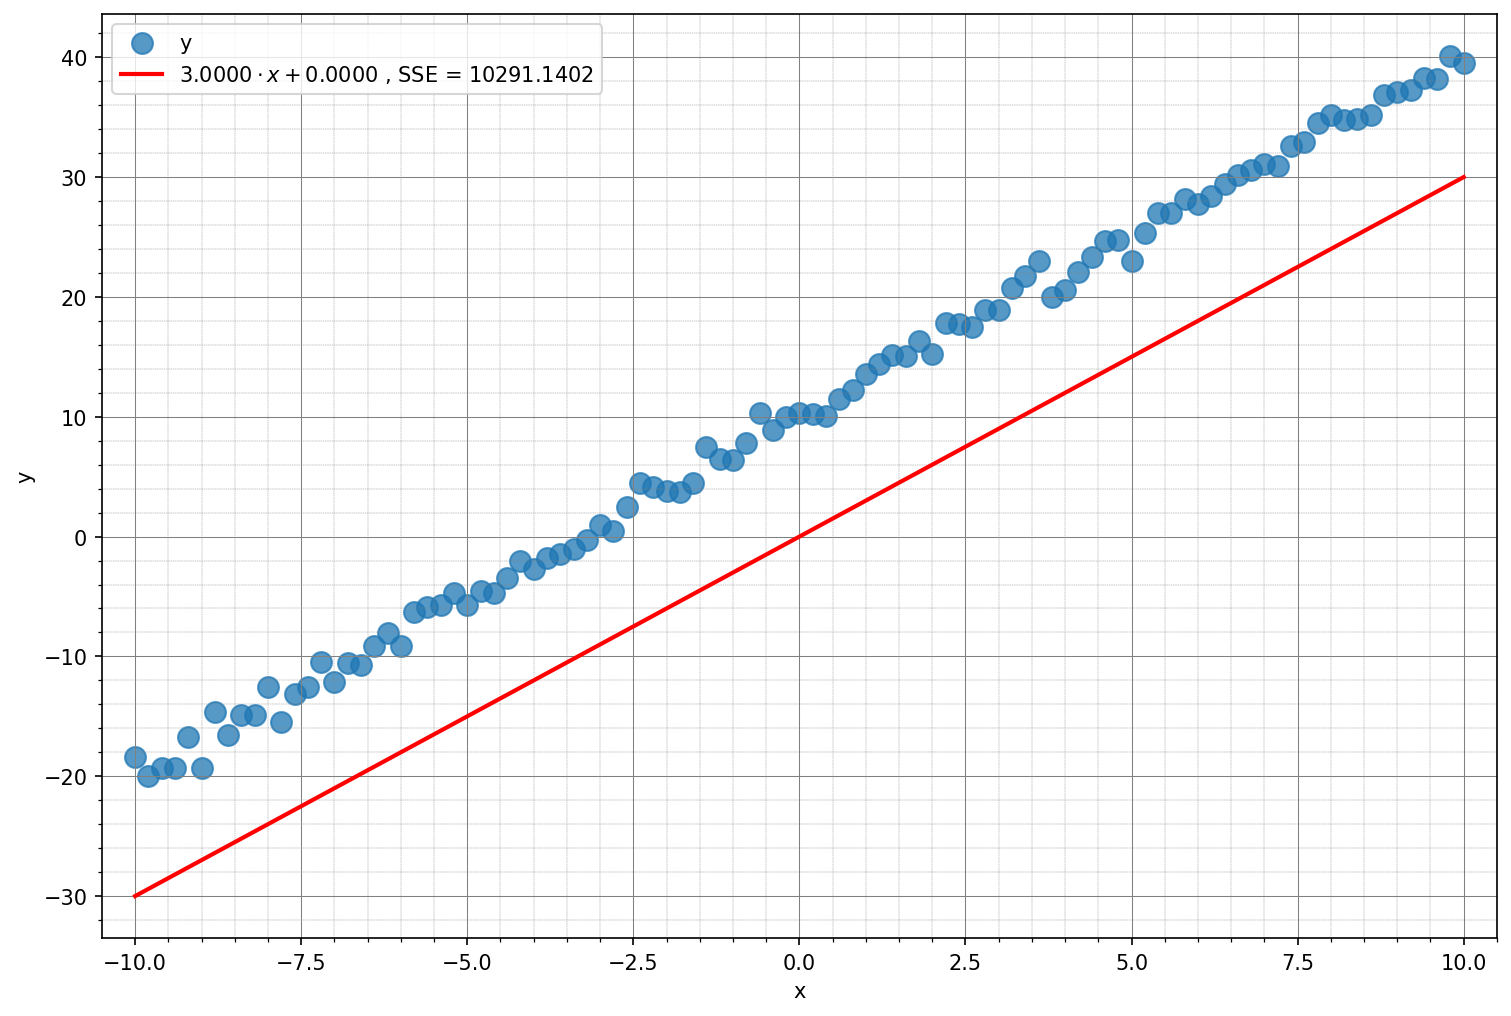

In [30]:
_ = plot_data(x, y, y_hat=linear_model(x, a_best, 0), a=a_best, b=0, sse=SSE_best, lim_y=(None, None))

### Intercepts only

Now we ignore the slopes and look for the best intercept.

In [31]:
intercepts = np.linspace(start=b_real - 25, stop=b_real + 25, num=51)

We prepare a vector `SSEs` to store all values of SSE for each of the intercepts.

In [32]:
SSEs = np.zeros(len(intercepts))

And again, we test them all.

In [33]:
for i, b in enumerate(intercepts):
    y_hat = linear_model(x, 0, b)
    SSEs[i] = calc_sse(y, y_hat)

Let's plot the result of our second parameter scan.

In [34]:
# Let's find the best SSE and the corresponding best intercept b
SSEs = np.asarray(SSEs)
SSE_best = SSEs.min()
b_best = intercepts[np.argmin(SSEs)]
b_best

10.0

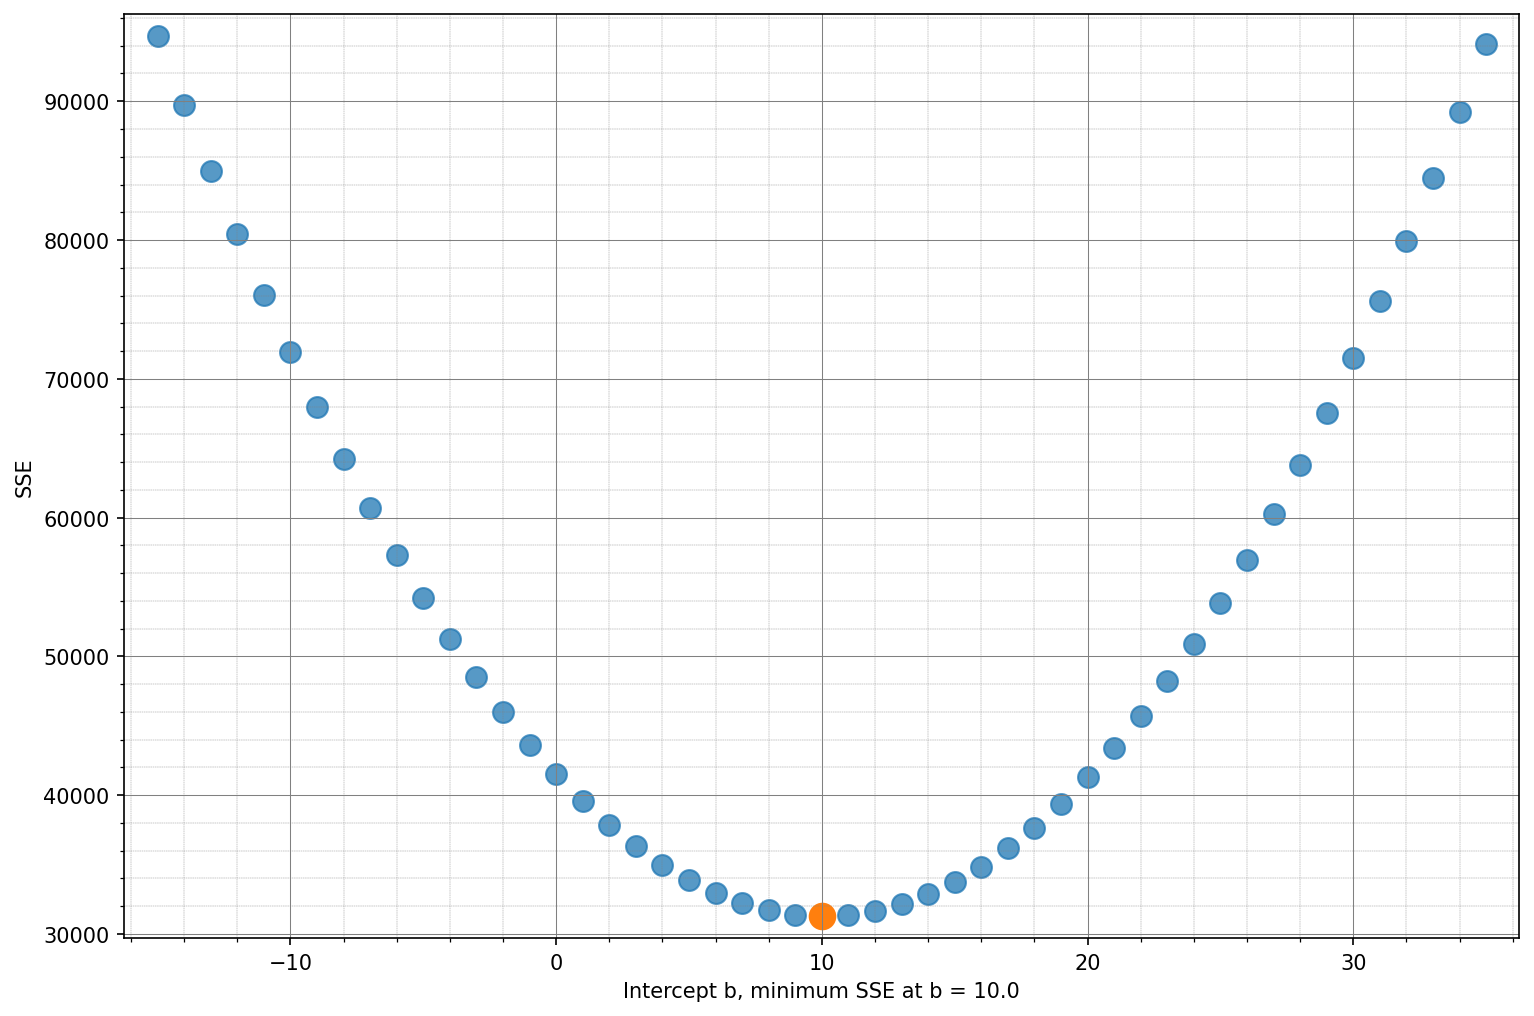

In [35]:
plot_parameter_search_1d(intercepts, SSEs, b_best, SSE_best, f"Intercept b, minimum SSE at b = {b_best}")

Let's plot ths model as well.

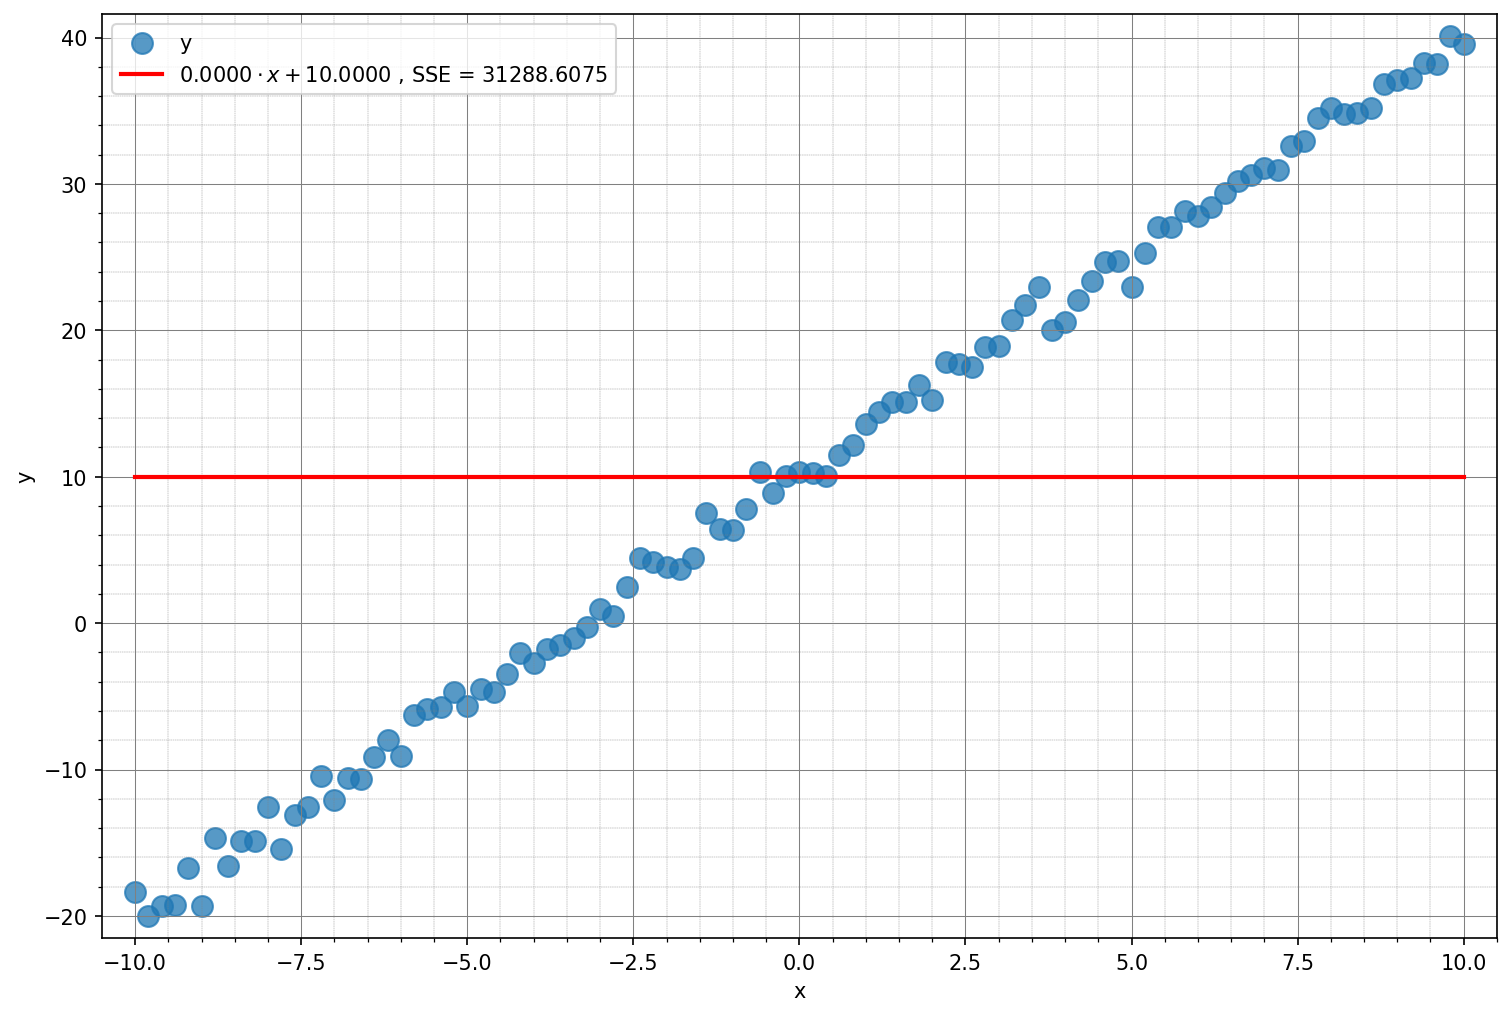

In [36]:
_ = plot_data(x, y, y_hat=linear_model(x, 0, b_best), a=0, b=b_best, sse=SSE_best)

### Slopes and intercepts at the same time

This time, we want to find the **combination of slope and intercept** with the smallest SSE. We will use the same slopes and intercepts as before.

We prepare a matrix to store all values of SSE for each of the `(slope, intercept)` pairs.

In [37]:
SSEs = np.zeros((len(slopes), len(intercepts)))

Now we test all combinations.

In [38]:
for i, a in enumerate(slopes):
    for j, b in enumerate(intercepts):
        y_hat = linear_model(x, a, b)
        SSEs[i, j] = calc_sse(y, y_hat)

Let's find the best values for the slope `a` and the intercept `b`.

In [39]:
a_best_index, b_best_index = np.where(SSEs == np.min(SSEs))
a_best = slopes[a_best_index]
b_best = intercepts[b_best_index]

Let's look at the results of the combined search.

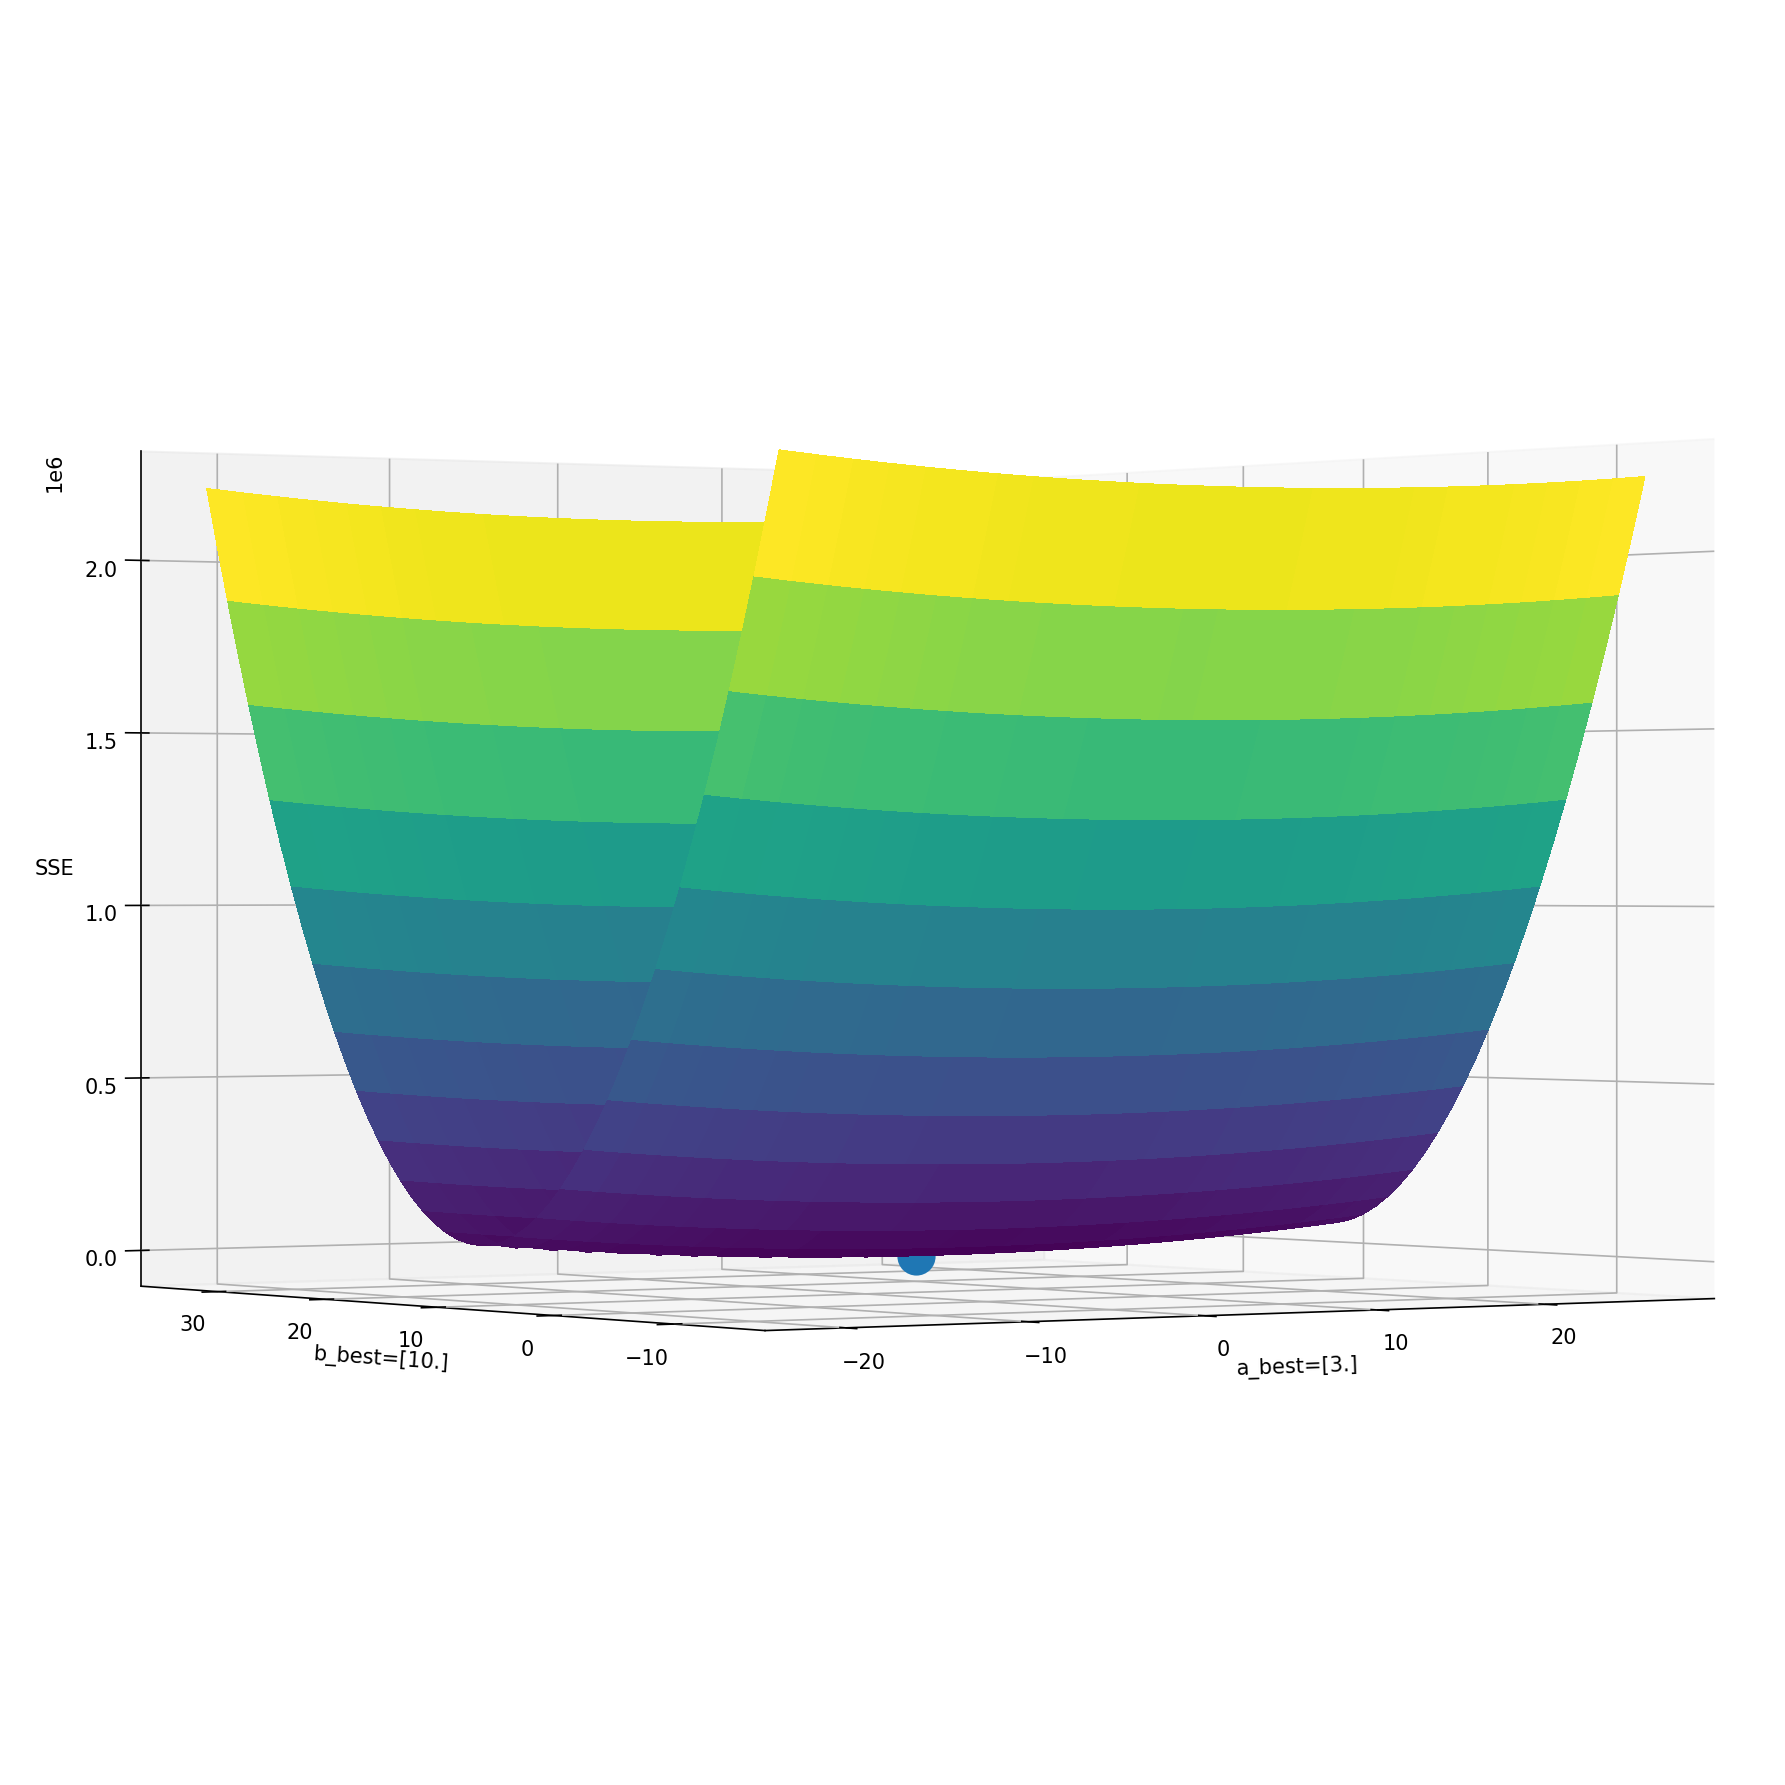

In [40]:
plot_parameter_search_2d(slopes, intercepts, SSEs, label_x=f"a_best={a_best}", label_y=f"b_best={b_best}", axis_angle=(0.0, 235.0))

## Using proper optimization techniques

With our grid approach we are limited by the resolution of the grid itself. A proper search of the minimum of SSE requires more advanced **optimization techniques**. 

The [SciPy library](https://www.scipy.org/) provides the function [`fmin`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fmin.html#scipy.optimize.fmin) in their [`optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html#module-scipy.optimize) package, that uses numerical analysis techniques to find the minimum of multi-parameter functions.

### What we minimize

We try to find the parameters `a_best` and `b_best` that plugged into our linear model `ax + b` result in a predicted value `y_hat` that minimizes the error from the real data `y` (i.e., the SSE). So, the function to minimize is `calc_sse()`, with the constraint that internally we need to keep recalculating the value of `y_hat` to update the current value of `SSE` (that should be minimal).

We can define our **objective function** to minimize `objf` that takes a tuple of parameters `(a, b)` that are the ones that are optimized, and additional argument `x`, and `y` that we need to calculate the SSE but that are not modified by `scipy.optimize.fmin()`.

In [41]:
def calc_sse(y, y_hat):
    """Calculate the Sum of Squared Errors between prediction y_hat and data y."""
    sse = np.sum(np.power(y_hat - y, 2))
    return sse

def linear_model(x, a, b):
    """Our linear model y = a * x + b."""
    y_hat = a * x + b
    return y_hat

def objf(params, x, y):
    """Our objective function."""
    a = params[0]
    b = params[1]
    y_hat = linear_model(x, a, b)
    sse = calc_sse(y, y_hat)
    return sse

Now we can plug `objf` into the `scipy.optimize.min()` function and find the values for `a` and `b` that minimize the SSE.

In [42]:
# Starting values for the optimization (initial values for a and b)
starting_values = (0.0, 0.0)

# Run the optimization
res = optimize.fmin(objf, starting_values, args=(x, y))

Optimization terminated successfully.
         Current function value: 77.859336
         Iterations: 87
         Function evaluations: 164


Let's have a look at the results.

In [43]:
a_est = res[0]
b_est = res[1]

print(f"Real values: (slope = {a_real:.4f}, intercept = {b_real:.4f}), estimated parameters: (slope = {a_est:.4f}, intercept = {b_est:.4f}).")

Real values: (slope = 3.0000, intercept = 10.0000), estimated parameters: (slope = 3.0147, intercept = 10.0555).


We can calculate `y_hat` and `sse` using the pobtained parameters.

In [44]:
y_hat = linear_model(x, a_est, b_est)
sse = calc_sse(y, y_hat)

Let's plot the results.

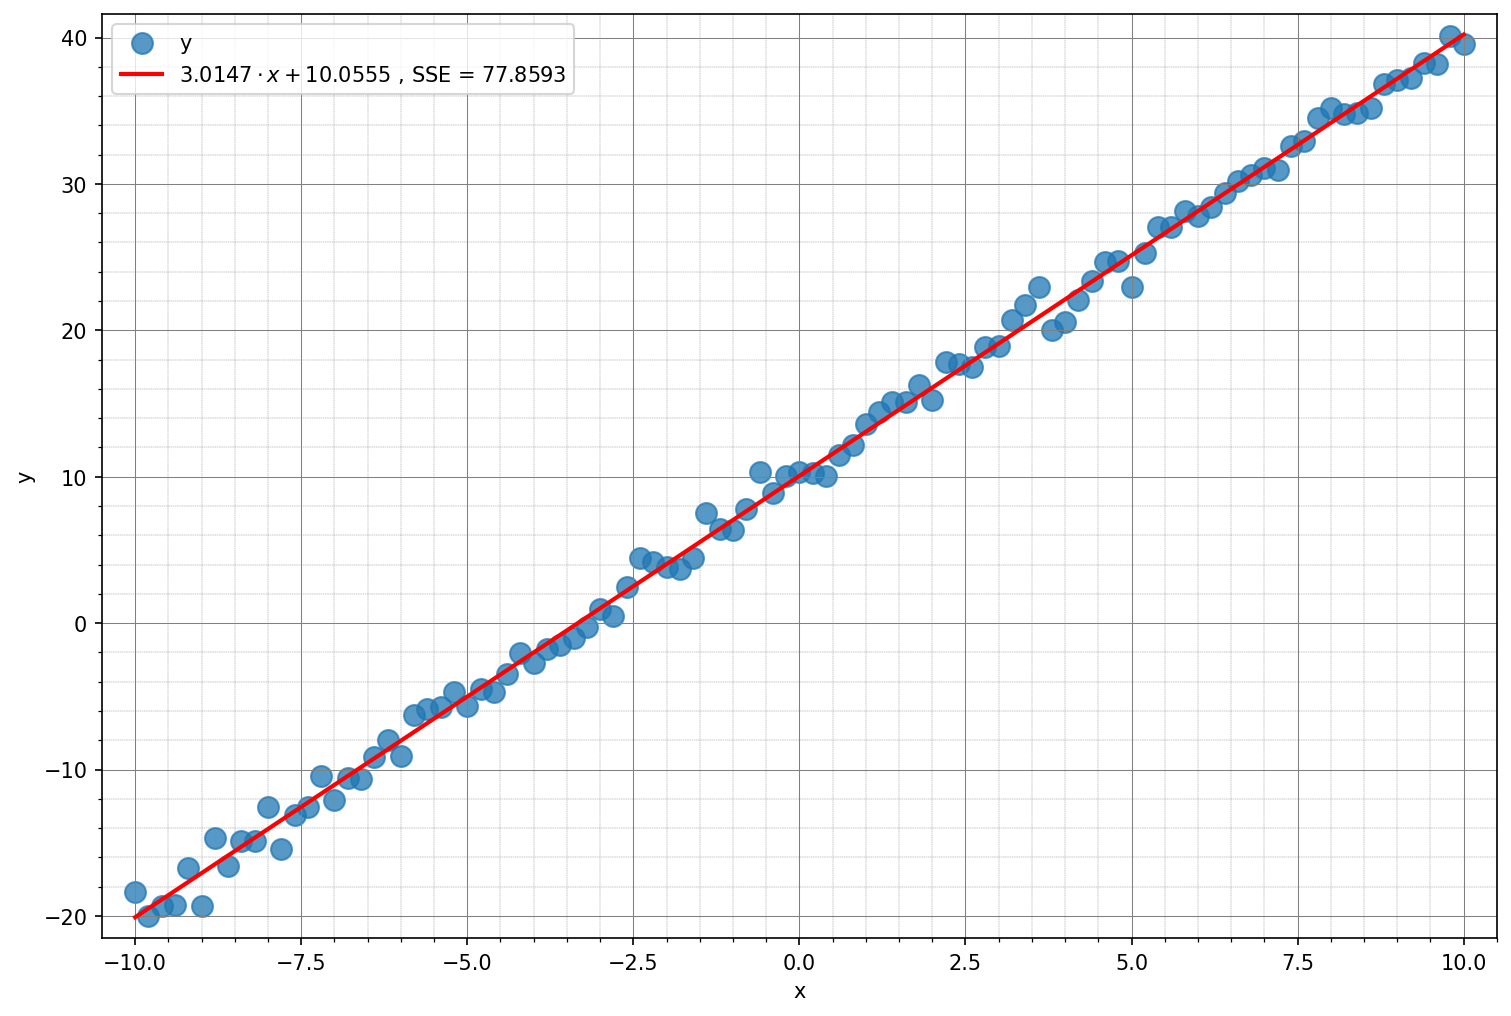

In [45]:
_ = plot_data(x, y, y_hat=y_hat, a=a_est, b=b_est, sse=sse)

The value of SSE for the optimal solution is slightly lower than the value from our naïve fits.

# Part 2 - Use confidence on repeated measurements to drive the fitting

## Fitting with repetitions

Let's consider the case where we have several measures `y` for each value `x`. We want to fit a line that takes those repetitions into consideration.

### Create some data to work with

These are the parameters for the second part of our demo.

In [46]:
nReps = 5   # Number of repeated (independent) measurements y.
w0    = 3.0 # Noise level on the repeated measurement example.

We create `nReps` lines with some error. We also reduce a bit the density of the data points for clarity.

In [47]:
x = np.linspace(start=x[0], stop=x[-1], num=21)
yy = np.zeros((nReps, len(x)))
for i in range(nReps):
    yy[i, :] = a_real * x + b_real + w0 * rng.randn(len(x))

yy.shape

(5, 21)

Let's also repeat `x` `nReps` times to have the same number of values.

In [48]:
xx = np.repeat(np.reshape(x, (1, len(x))), nReps, axis=0)

xx.shape

(5, 21)

Now we can plot the five repetition `y` for each value of `x`.

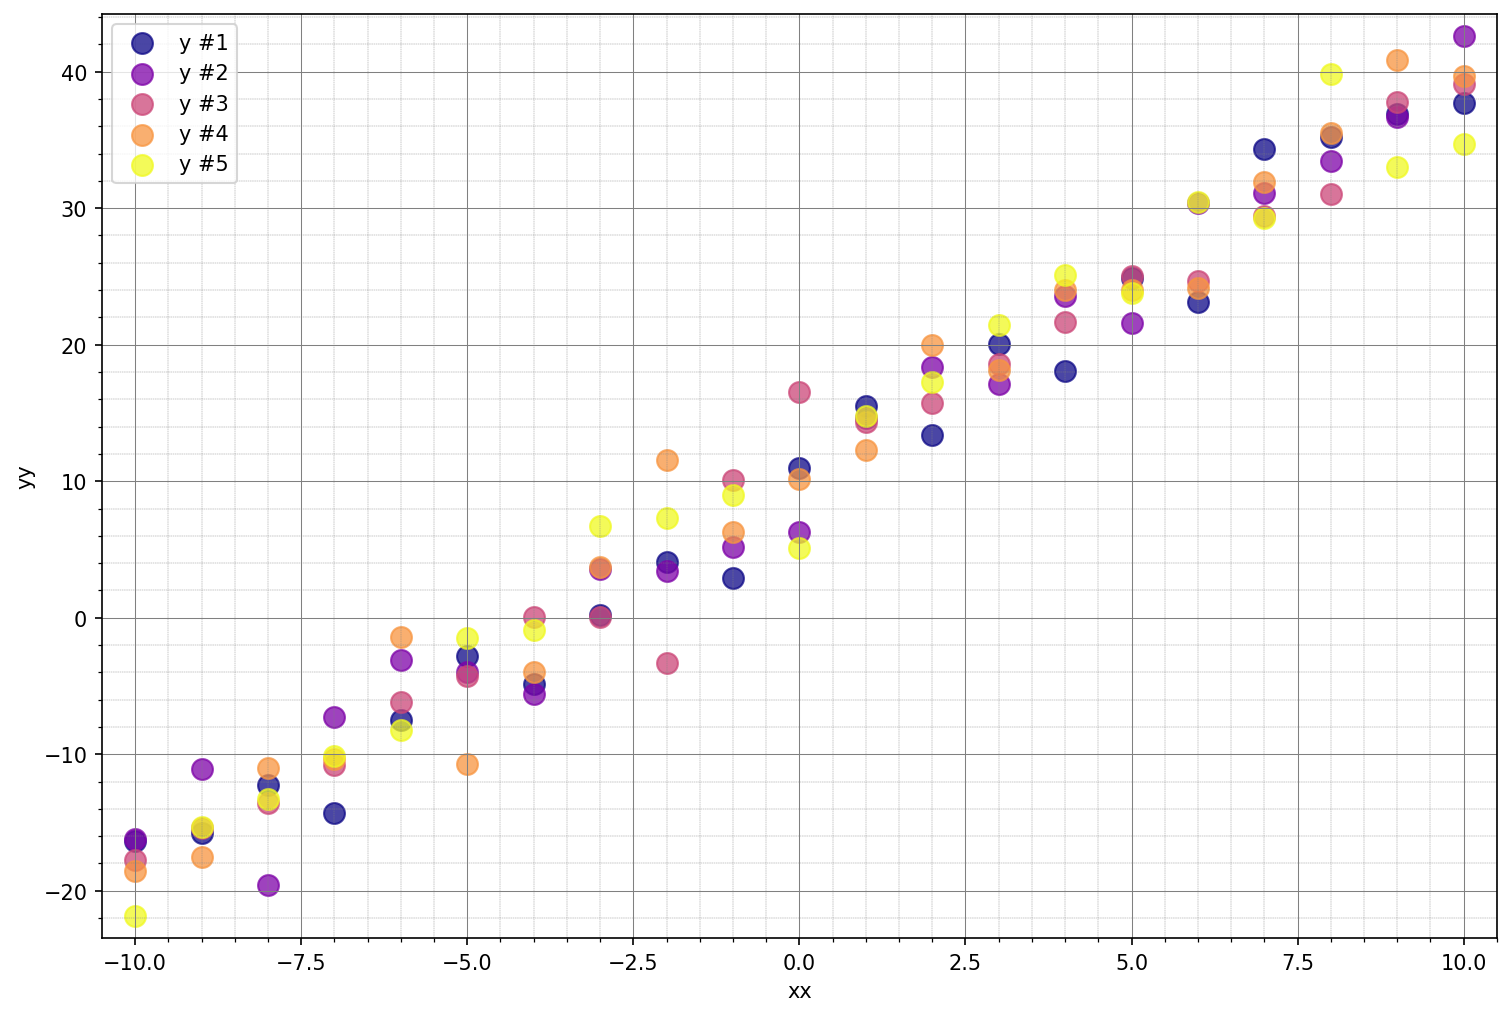

In [49]:
_ = plot_data(xx, yy, label_x="xx", label_y="yy")

### Use `scipy.optimize.fmin()` to find the optimal parameters `a` and `b`

We redefine the same functions as above.

In [50]:
def calc_sse(y, y_hat):
    """Calculate the Sum of Squared Errors between prediction y_hat and data y."""
    sse = np.sum(np.power(y_hat - y, 2))
    return sse

def linear_model(x, a, b):
    """Our linear model y = a * x + b."""
    y_hat = a * x + b
    return y_hat

def objf(params, x, y):
    """Our objective function."""
    a = params[0]
    b = params[1]
    y_hat = linear_model(x, a, b)
    sse = calc_sse(y_hat, y)
    return sse

Let's plug our objective function into `fmin()` and run the optimization.

In [51]:
# Starting values for the optimization (initial values for a and b)
starting_values = (0.0, 0.0)

# Run the optimization
res_reps = optimize.fmin(objf, starting_values, args=(xx, yy))

Optimization terminated successfully.
         Current function value: 838.594220
         Iterations: 83
         Function evaluations: 160


Let's look at the results again.

In [52]:
a_est_reps = res_reps[0]
b_est_reps = res_reps[1]

print(f"Real values: (slope = {a_real:.4f}, intercept = {b_real:.4f}), estimated parameters: (slope = {a_est_reps:.4f}, intercept = {b_est_reps:.4f}).")

Real values: (slope = 3.0000, intercept = 10.0000), estimated parameters: (slope = 2.9072, intercept = 10.4128).


Let's calculate `y_hat`:

In [53]:
y_hat = linear_model(x, a_est, b_est)

We can now look at the fit.

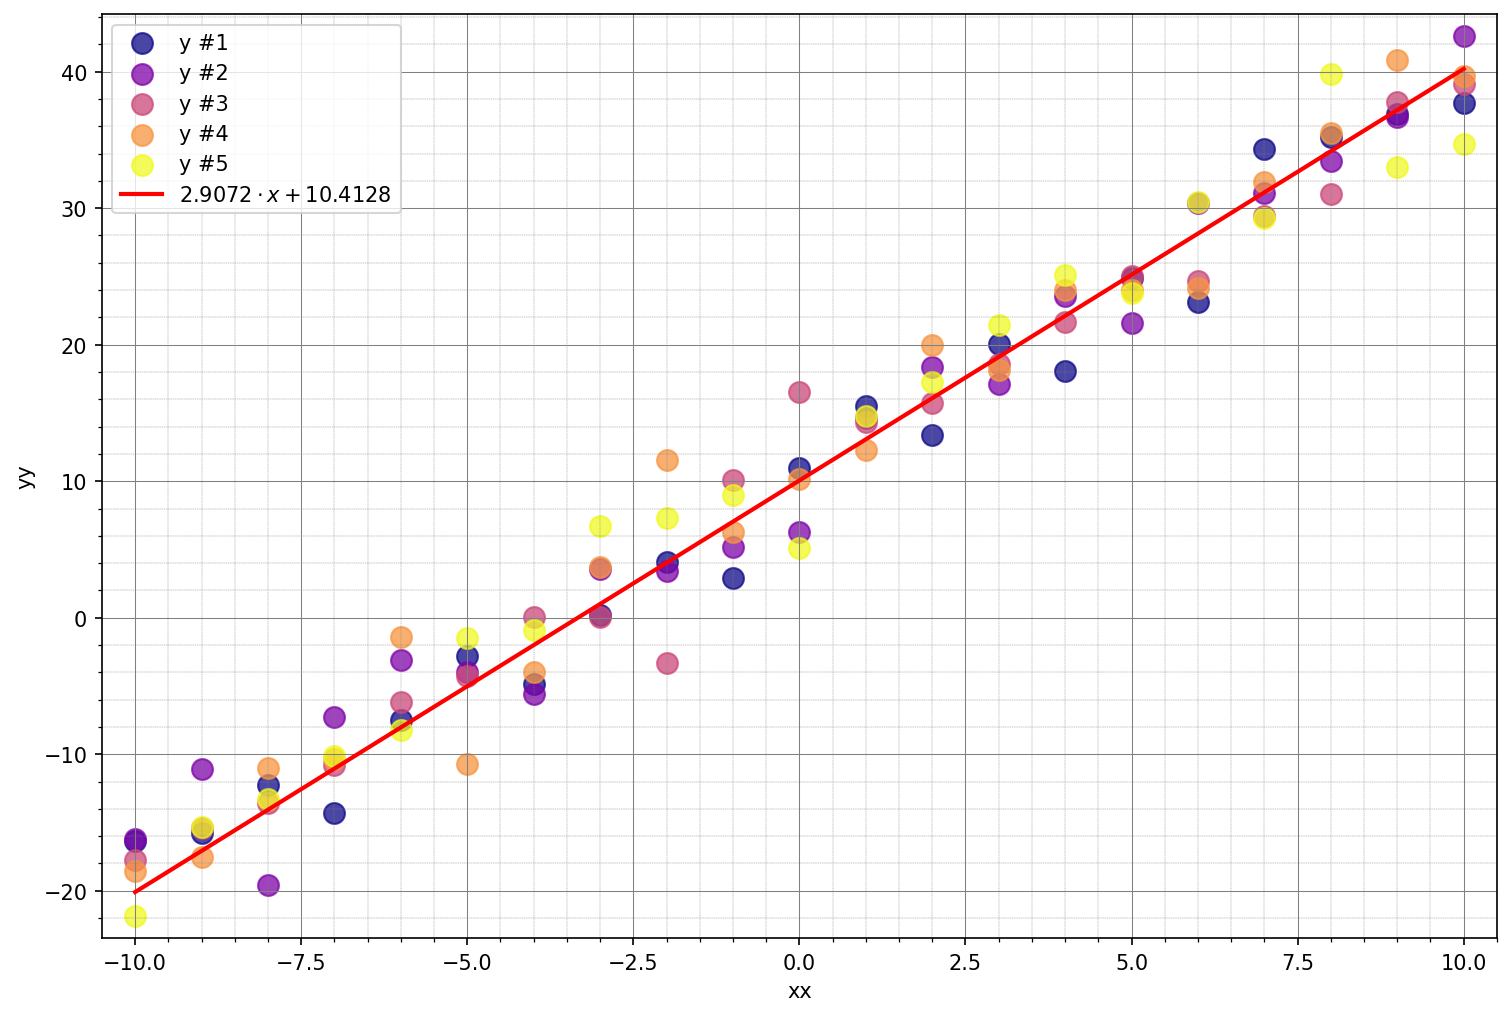

In [54]:
_ = plot_data(xx, yy, x2=x, y_hat=y_hat, a=a_est_reps, b=b_est_reps, label_x="xx", label_y="yy")

### Comparison with fitting the mean of all `y` values

Instead of considering all `nReps` repetitions of y independently, let's calculate the mean of each of the repetitions per value of `x`.

In [55]:
yy_mean = yy.mean(axis=0)
yy_mean

array([-18.12408528, -15.02713001, -13.93977791, -10.57203663,
        -5.28019972,  -4.65497579,  -3.04870472,   2.85589338,
         4.63374333,   6.683321  ,   9.81298693,  14.32844057,
        16.950925  ,  19.06852859,  22.4882504 ,  23.86821563,
        26.56931009,  31.2412797 ,  35.0100201 ,  37.05022633,
        38.75556868])

Now, let's find the best parameters `a` and `b` that fit this new line `yy_mean`.

In [56]:
# Starting values for the optimization (initial values for a and b)
starting_values = (0.0, 0.0)

# Run the optimization
res_mean = optimize.fmin(objf, starting_values, args=(x, yy_mean))

Optimization terminated successfully.
         Current function value: 18.857837
         Iterations: 83
         Function evaluations: 160


Let's look at the new results and compare them with the previous ones, where we used all `y` data points.

In [57]:
a_est_mean = res_mean[0]
b_est_mean = res_mean[1]

print(f"All data:   (slope = {a_est_reps:.8f}, intercept = {b_est_reps:.8f})\n" +
      f"From mean:  (slope = {a_est_mean:.8f}, intercept = {b_est_mean:.8f})\n" +
      f"Difference: (        {a_est_reps - a_est_mean:.8f},             {b_est_reps - b_est_mean:.8f})\n")

All data:   (slope = 2.90722397, intercept = 10.41279796)
From mean:  (slope = 2.90722397, intercept = 10.41279796)
Difference: (        0.00000000,             0.00000000)



In [58]:
y_hat = linear_model(x, a_est_mean, b_est_mean)

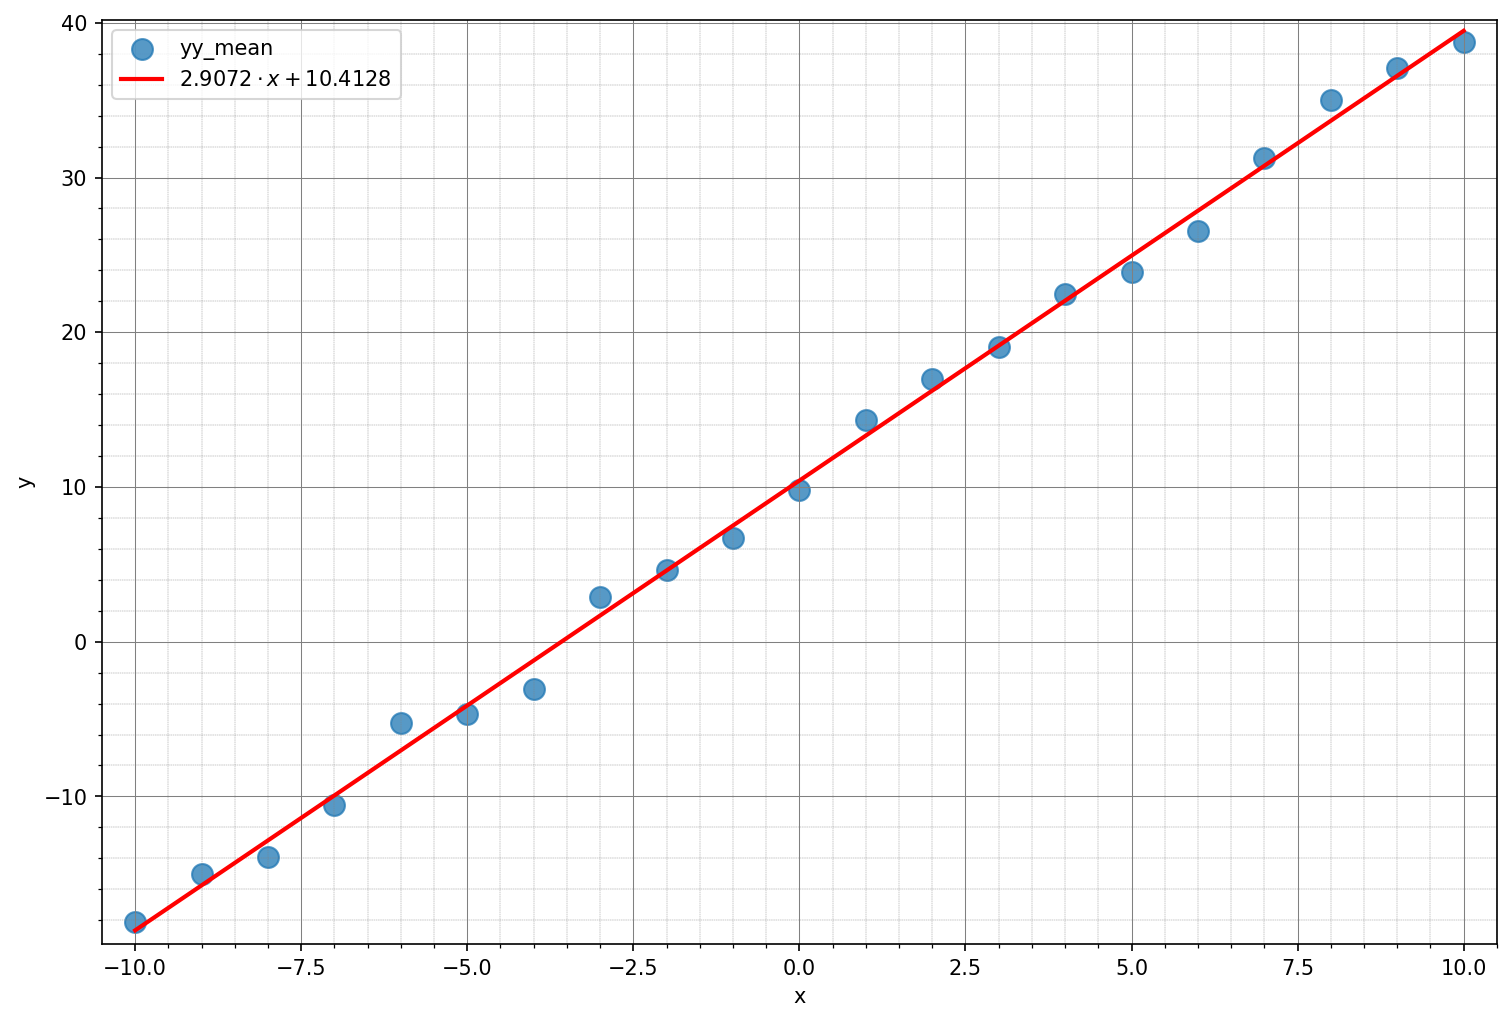

In [59]:
_ = plot_data(x, yy_mean, y_hat=y_hat, a=a_est_mean, b=b_est_mean, data_name="yy_mean")

The result of fitting all `nReps` repetitions is exactly the same as the result of fitting the mean of the `nReps` `y` values for each value of `x`.

## Weighted fitting

Let's consider the case where we have several lines and we use their average as the data we want to fit. Since we have several measures for the same values, we can use their standard error to weight the individual points in the fit.

### Create some data to work with

These are the parameters for the third part of our demo.

In [60]:
# We reset the random number generator so that we can recreate this same dataset later
rng = np.random.RandomState(1)

In [61]:
nReps       = 5   # Number of repeated (independent) measurements y.
w0          = 3.0 # Noise level on the repeated measurement example.
w1          = 0.5 # Weight that scales the standard deviation of the noise for the first half of the data.
w2          = 5.0 # Weight that scales the standard deviation of the noise for the second half of the data.
data_offset = 5.0 # Amount by which the second half of the data is moved away from the ideal fit.

We create `nReps` lines with some error. The first half of the points has an error of `+/- w1`, whereas the second half has an error of `+/- w2`. Furthermore, we shift the second half of the data by a constant value `data_offset`.

In [62]:
x = np.linspace(start=x[0], stop=x[-1], num=21)

n1 = len(x) // 2
n2 = len(x) - n1

yy = np.zeros((nReps, len(x)))
for i in range(nReps):
    noise = np.zeros(len(x))
    noise[:n1] = w1 * rng.randn(n1)
    noise[n1:] = data_offset + w2 * rng.randn(n2)
    yy[i, :] = a_real * x + b_real + w0 * noise

yy.shape

(5, 21)

Again, we replicate `x` `nReps` times to have the same number of elements in `x` and `y`.

In [63]:
xx = np.repeat(np.reshape(x, (1, len(x))), nReps, axis=0)

xx.shape

(5, 21)

Let's plot the data.

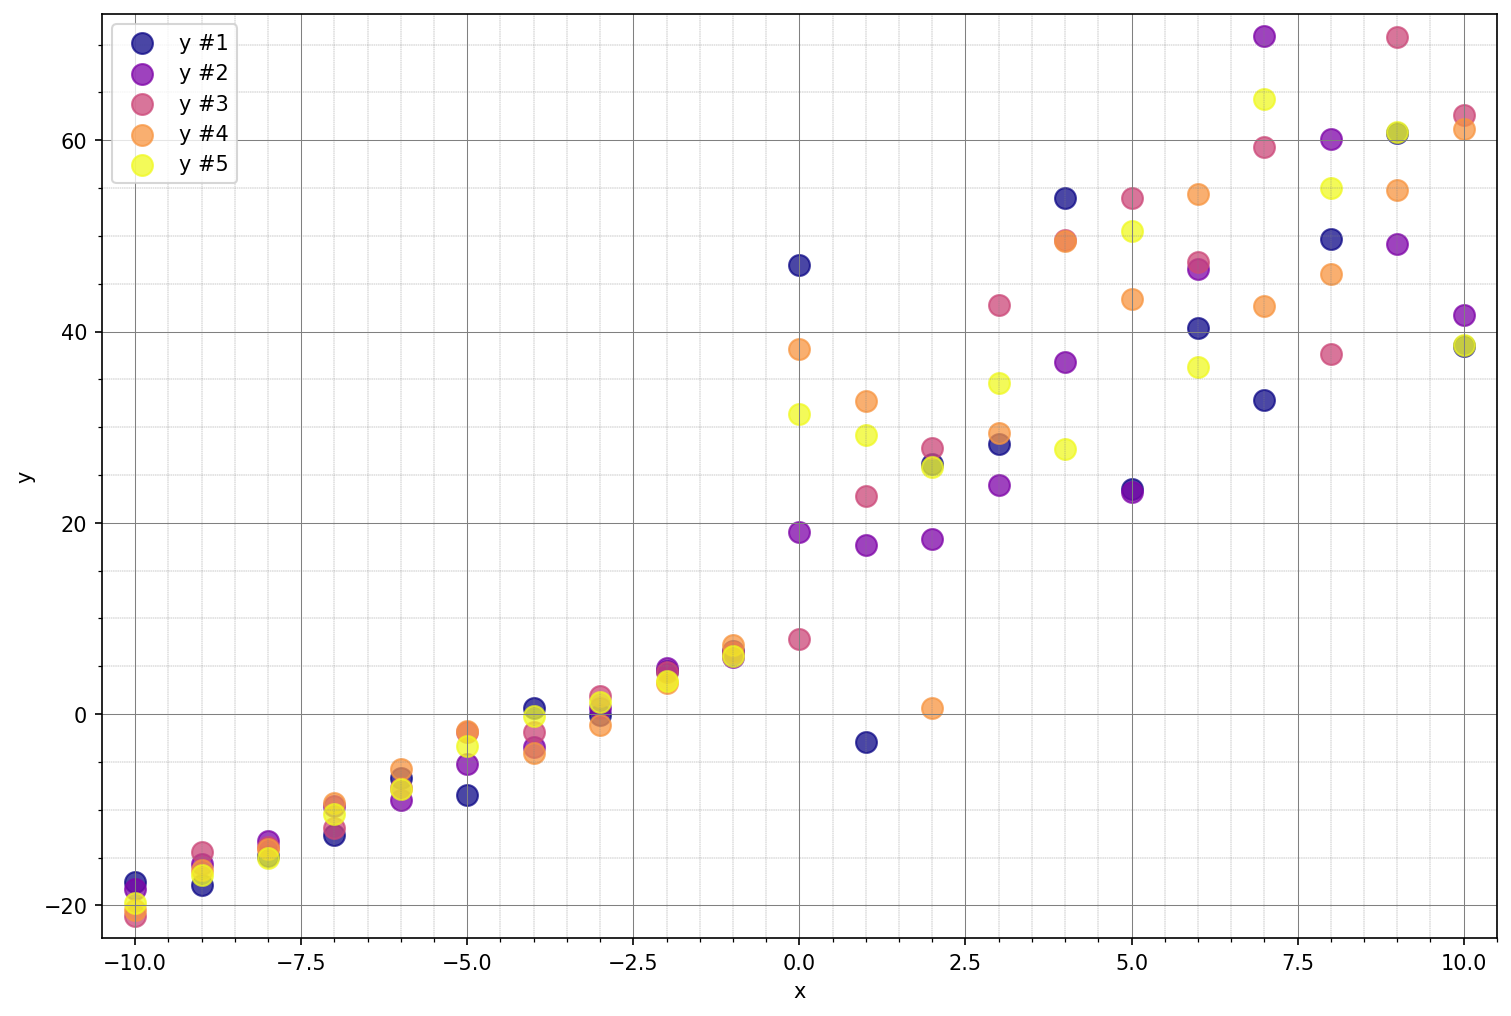

In [64]:
_ = plot_data(xx, yy)

### Fit the data as usual

Let's define again the functions we want to optimize.

In [65]:
def calc_sse(y, y_hat):
    """Calculate the Sum of Squared Errors between prediction y_hat and data y."""
    sse = np.sum(np.power(y_hat - y, 2))
    return sse

def linear_model(x, a, b):
    """Our linear model y = a * x + b."""
    y_hat = a * x + b
    return y_hat

def objf(params, x, y):
    """Our objective function."""
    a = params[0]
    b = params[1]
    y_hat = linear_model(x, a, b)
    sse = calc_sse(y_hat, y)
    return sse

In [66]:
# Starting values for the optimization (initial values for a and b)
starting_values = (0.0, 0.0)

# Run the optimization
res_reps = optimize.fmin(objf, starting_values, args=(xx, yy))

Optimization terminated successfully.
         Current function value: 9162.133234
         Iterations: 86
         Function evaluations: 164


Let's see the results.

In [67]:
a_est_reps = res_reps[0]
b_est_reps = res_reps[1]

print(f"Estimated parameters: (slope = {a_est_reps:.4f}, intercept = {b_est_reps:.4f}).")

Estimated parameters: (slope = 4.1209, intercept = 17.9127).


How does the fit look like?

In [68]:
y_hat_reps = linear_model(x, a_est_reps, b_est_reps)

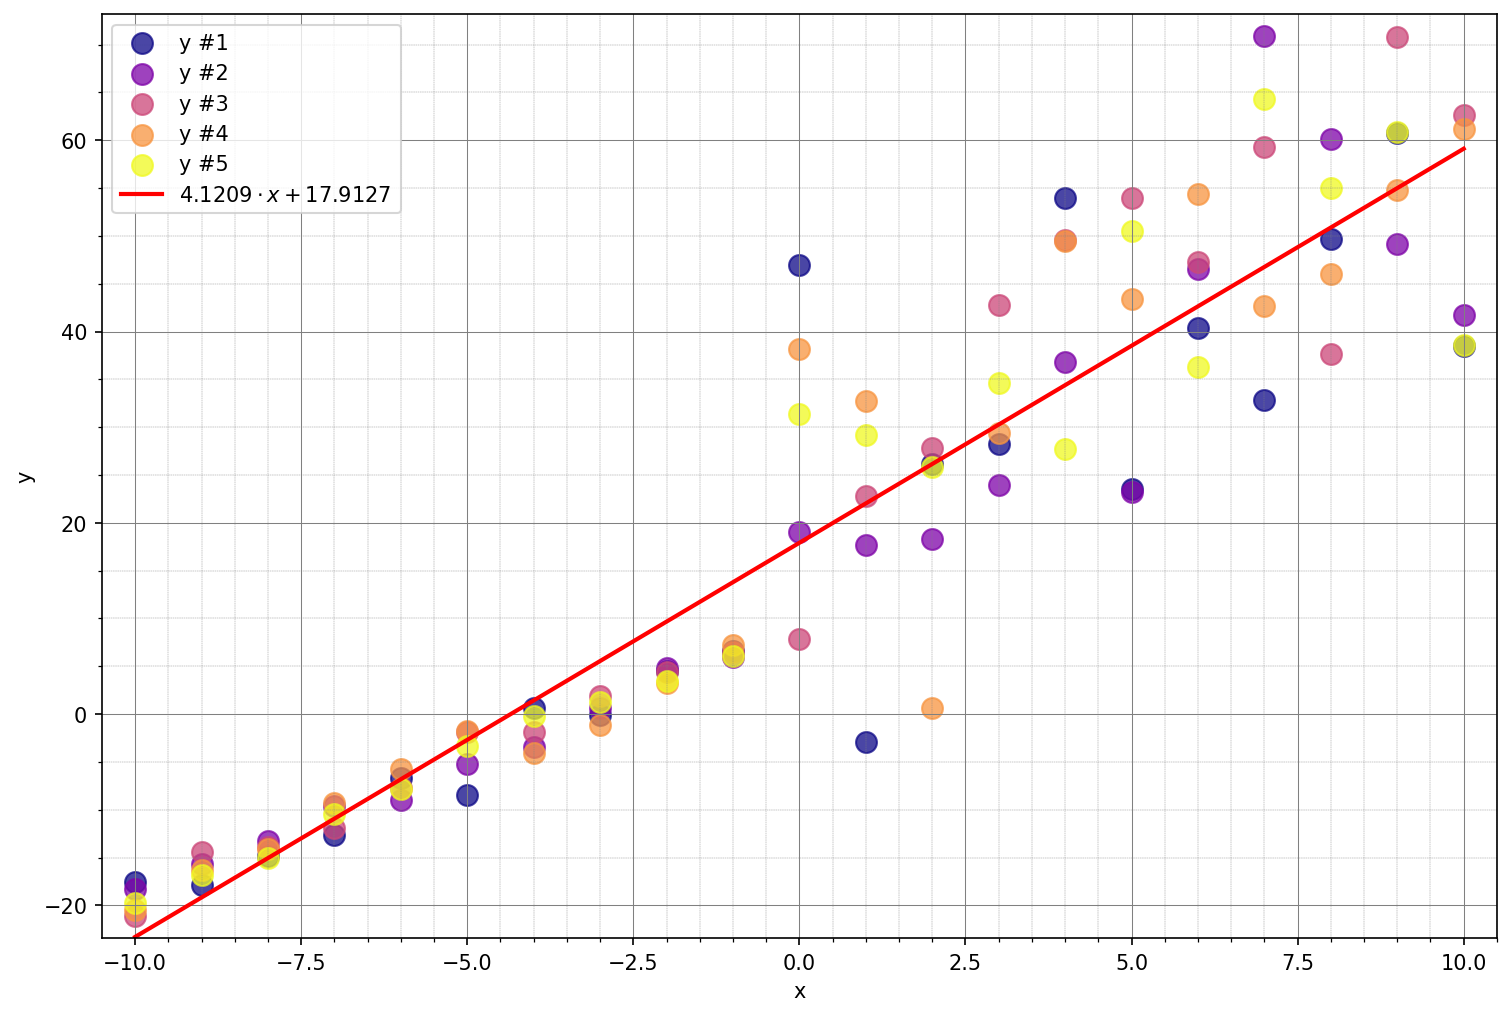

In [69]:
_ = plot_data(xx, yy, x2=x, y_hat=y_hat_reps, a=a_est_reps, b=b_est_reps)

### Calculate the standard error of the mean

The standard error of the mean can give as an idea of how badly the various replicates `y` for every value `x` represent the underlying, real value. We can calculate the standard error of the mean as follows:

In [70]:
# Calculate the standard error of the mean (per point)
sd = yy.std(axis = 0, ddof = 1)
se = sd / np.sqrt(nReps)

We can now plot the data with the standard errors superimposed.

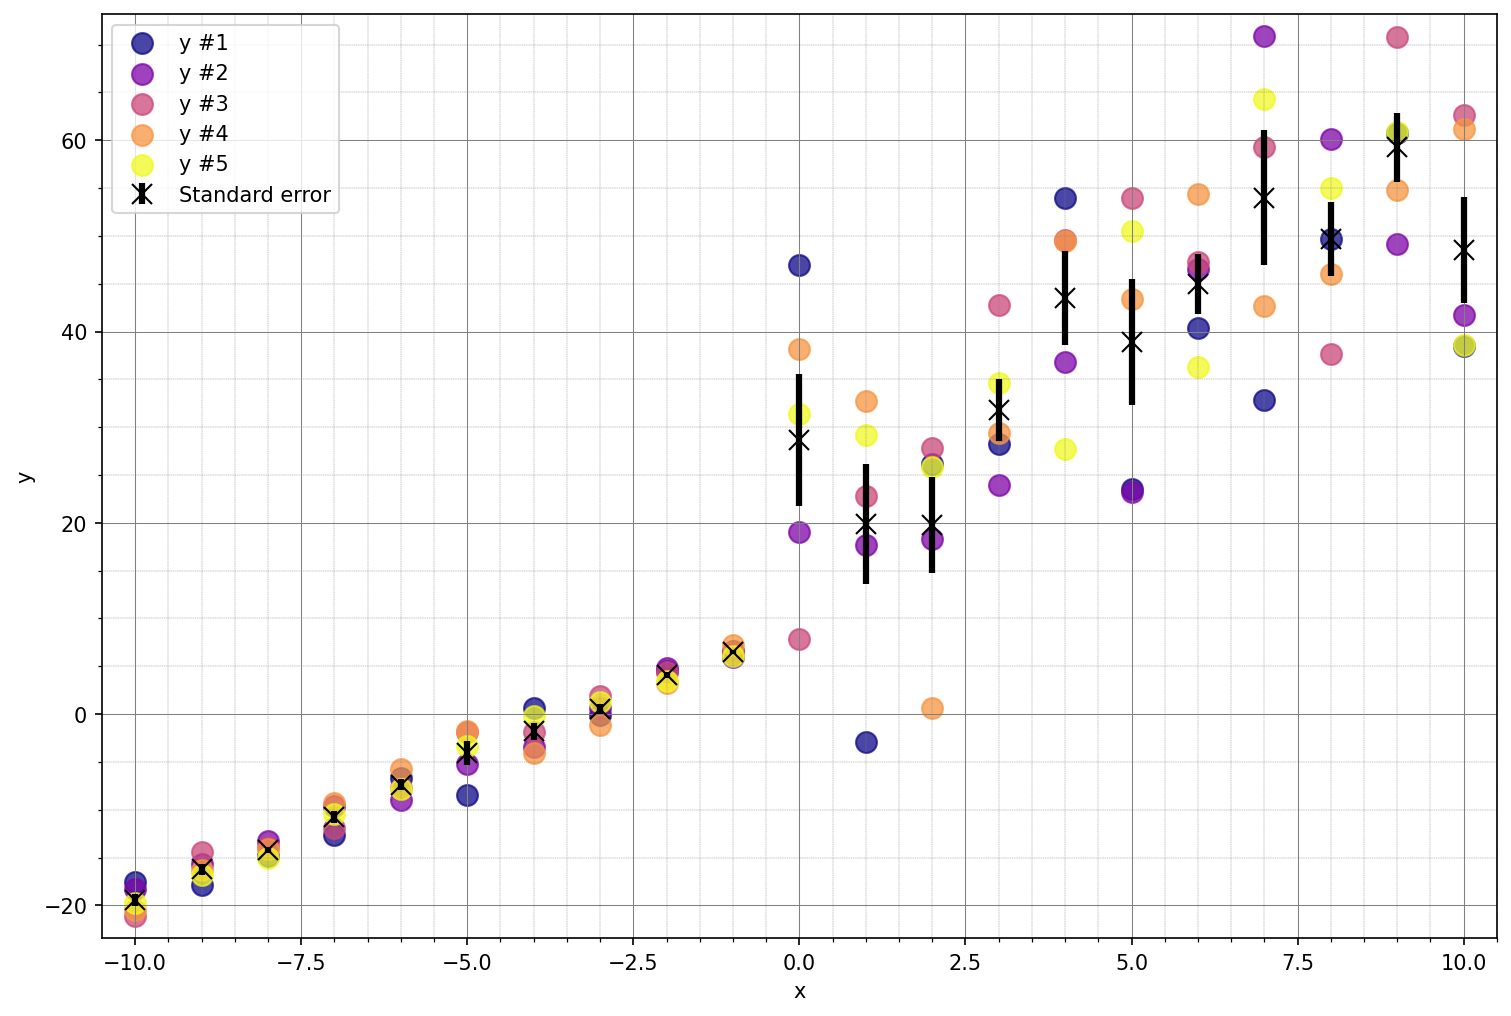

In [71]:
_ = plot_data(x, yy, errors=se, errors_label="Standard error")

### Change the objective function to use the standard error of the mean as weight

We will work again with `x` and `yy_mean`, but this time we will use the standard error of the means to weigh the different values `y_mean[i]` with the idea that bad `y` replicates should be penalised in the optimisation process.

In [72]:
# Let's recalculate yy_mean and the standard error of the mean (per point)
yy_mean = yy.mean(axis=0)

sd = yy.std(axis = 0, ddof = 1)
se = sd / np.sqrt(nReps)

We define a slightly modified version of the original `calc_sse()` function that now takes a vector `se` of standard errors as argument.

In [73]:
def calc_sse_weighed(y, y_hat, se):
    """Calculate the Sum of Squared Errors between prediction y_hat and data y."""
    sse = np.sum(np.power(y_hat - y, 2) / np.power(se, 2))
    return sse

def linear_model(x, a, b):
    """Our linear model y = a * x + b."""
    y_hat = a * x + b
    return y_hat

def objf_weighed(params, x, y, se):
    """Our objective function (that calls the weighed version of calc_sse())."""
    a = params[0]
    b = params[1]
    y_hat = linear_model(x, a, b)
    sse = calc_sse_weighed(y_hat, y, se)
    return sse

We need to pass the `se` vectors to `optimize.fmin()` as an additional argument.

In [74]:
# Starting values for the optimization (initial values for a and b)
starting_values = (0.0, 0.0)

# Run the optimization
res_reps_weighed = optimize.fmin(objf_weighed, starting_values, args=(x, yy_mean, se))

Optimization terminated successfully.
         Current function value: 155.148254
         Iterations: 82
         Function evaluations: 158


Let's have a look at the results.

In [75]:
a_est_weighed = res_reps_weighed[0]
b_est_weighed = res_reps_weighed[1]

print(f"Estimated parameters (using weights): (slope = {a_est_weighed:.4f}, intercept = {b_est_weighed:.4f}).")

Estimated parameters (using weights): (slope = 3.0586, intercept = 10.2718).


And finally, plot current fit along with the non-weighed one.

In [76]:
y_hat_weighed = linear_model(x, a_est_weighed, b_est_weighed)

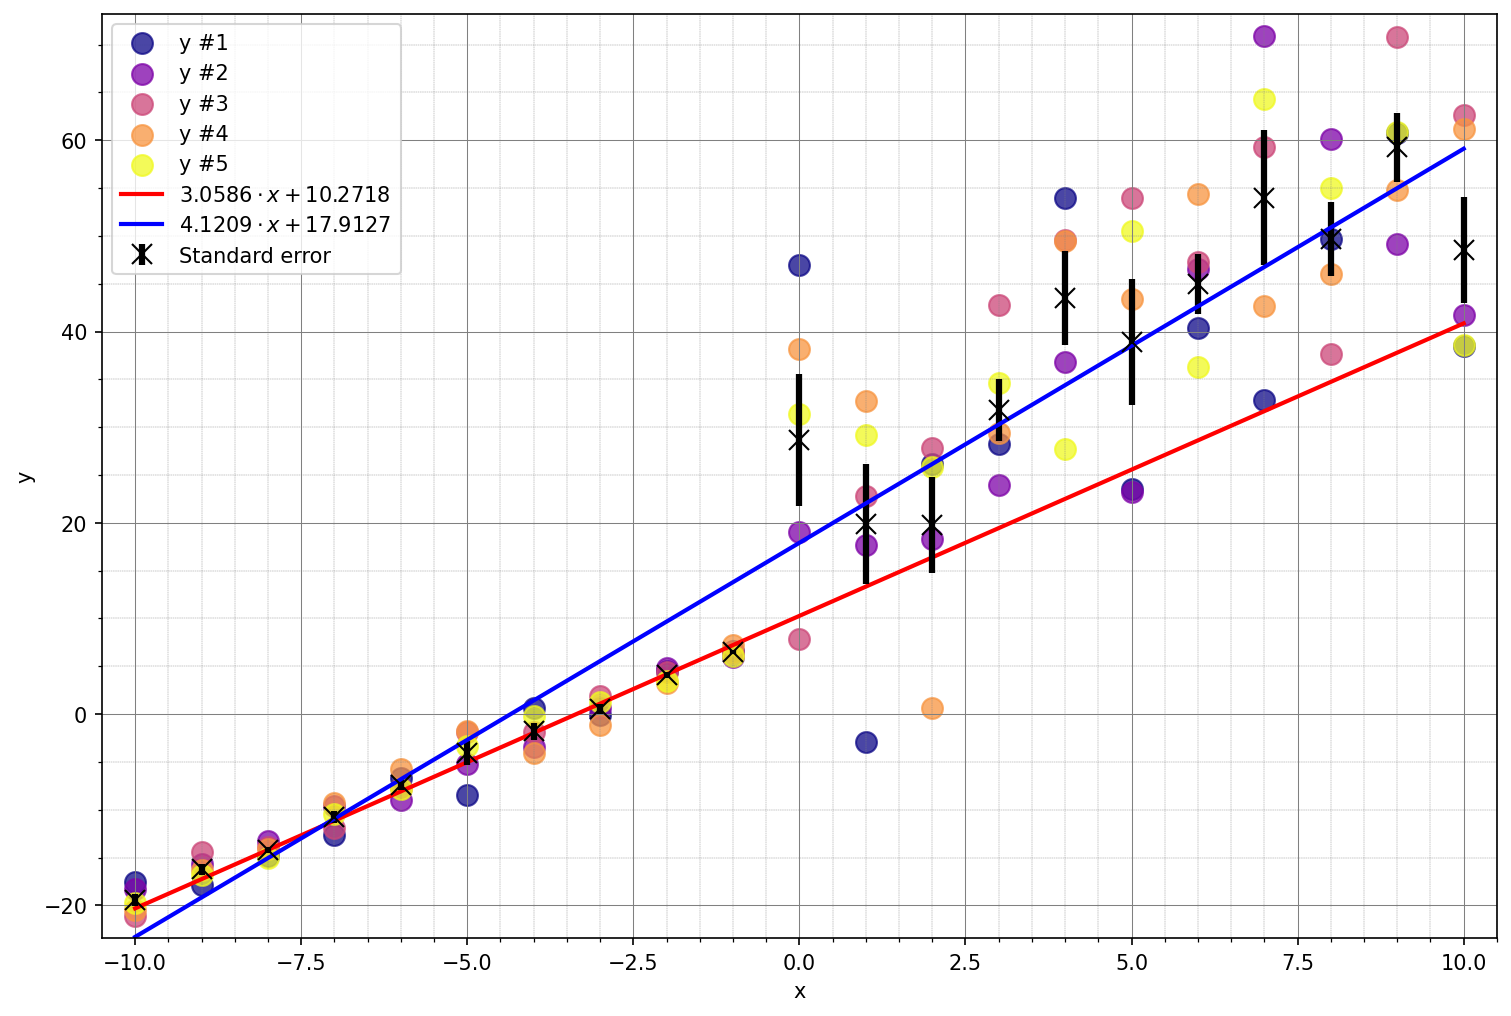

In [77]:
fig, ax = plot_data(x, yy, x2=x, y_hat=y_hat_weighed, a=a_est_weighed, b=b_est_weighed, errors=se, errors_label="Standard error")
_ = add_fit(fig, ax, x=x, y_hat=y_hat_reps, a=a_est_reps, b=b_est_reps)

As expected, the points with low standard error have much higher weight in driving the optimisation, and the fitted line passes much closer to these points than it does to the ones with large standard errors.

# Part 3: Another type of model

This builds on the intuitions about linear model fitting. The model we want to fit this time is `y = a * exp(b * x) + e`, where `x` and `y` are given and `a` and `b` are the parameters of our model that we want to estimate. The term `e` accounts for deviations between the model and the noisy data.

## Create some data to work with

These are the parameters for this part of the demo. We want to study cell proliferation, and we assume we measured cell counts (or biomass) at regulat intervals of 4 hours for 48 hours. An accepted model of cell proliferation is as simple exponential of the form: $$M(t)=M(0)e^{\lambda t}$$

Following code simulates the obtained measurements.

In [78]:
M0 = 500
lm = 0.05
noise = 0.05

For the sake of consistency in our notation, we will keep calling the independent variable `x` (representing time `t` in the previous equation), and the dependent variable `y` (indicating the number of cells `M`).

In [79]:
rng = np.random.RandomState(1)
x = np.linspace(start=0, stop=48, num=13)
M = M0 * np.exp(lm * x)
y = np.round(M + (noise * M) * rng.randn(len(M)))
print(y)

[ 541.  592.  726.  862. 1161. 1203. 1805. 1950. 2516. 2987. 3965. 4048.
 5423.]


Plot the data.

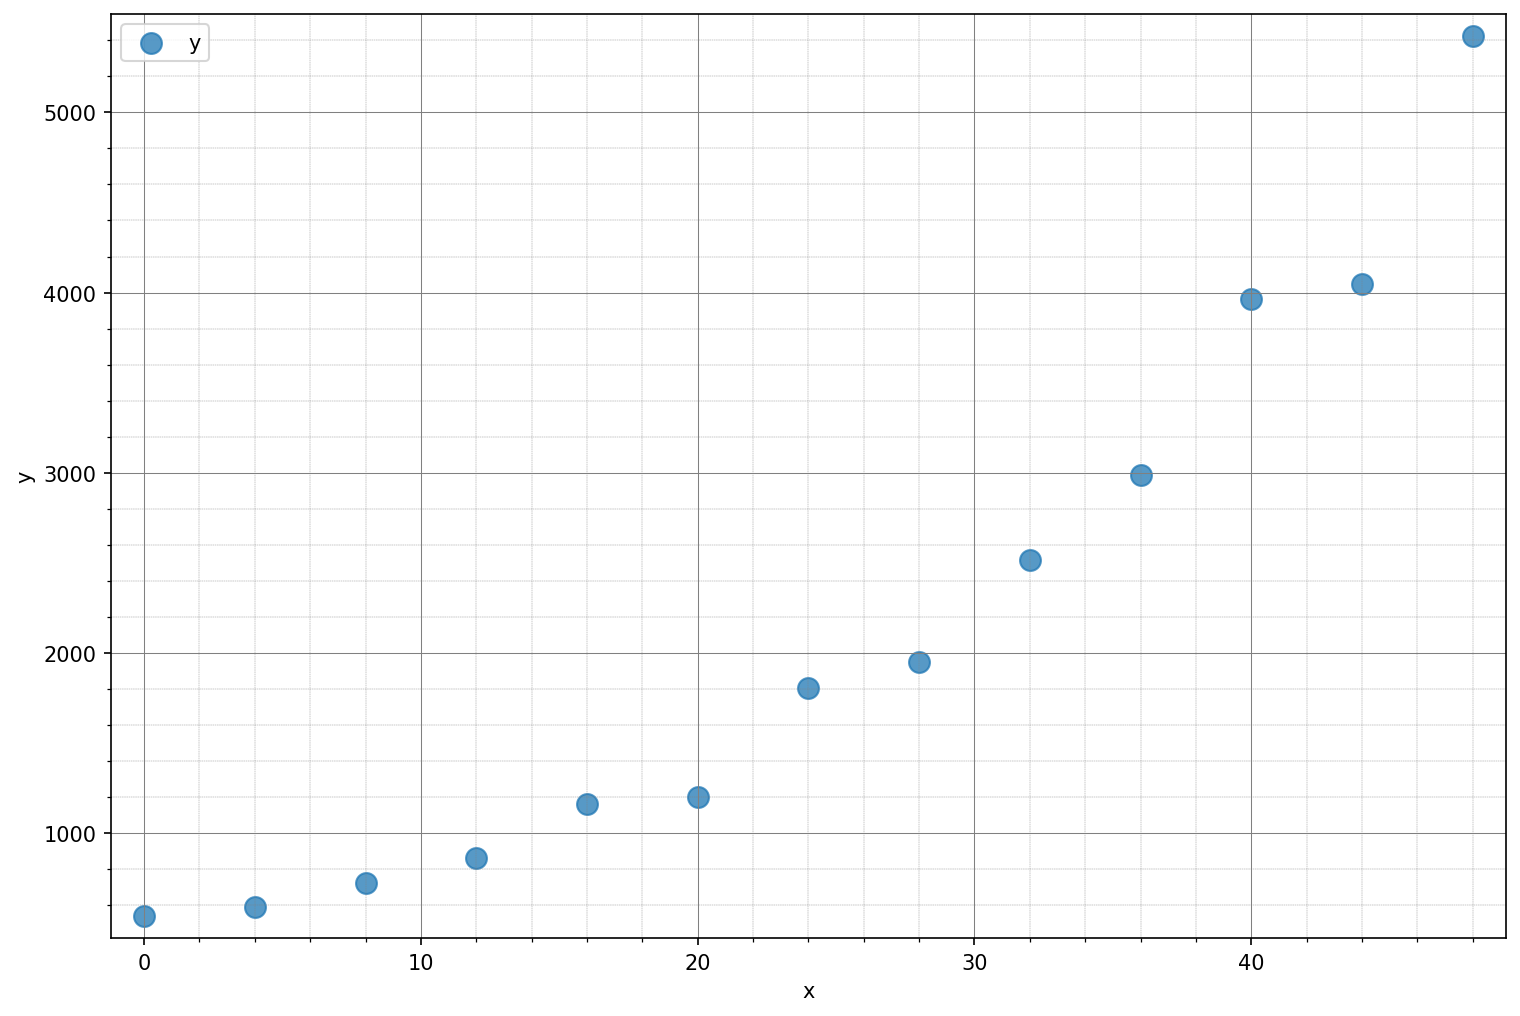

In [80]:
_ = plot_data(x, y)

## Fitting an exponential function

Exponentials are often used when the rate of change of a quantity is proportional to the initial amount of the quantity.

We can use again the `scipy.optimize.fmin()` function. This time, instead of using a linear model `ax + b`, we use an exponential model `a*exp(b*x)`.

In [81]:
def exponential_model(x, a, b):
    """Exponential model y_hat = a * exp(b * x)."""
    y_hat = a * np.exp(b * x)
    return y_hat

Let's define again our objective function, this time using the exponential function instead of the linear model we used earlier.

In [82]:
def calc_sse(y, y_hat):
    """Calculate the Sum of Squared Errors between prediction y_hat and data y."""
    sse = np.sum(np.power(y_hat - y, 2))
    return sse

def objf(params, x, y):
    """Our objective function."""
    a = params[0]
    b = params[1]
    y_hat = exponential_model(x, a, b)
    sse = calc_sse(y_hat, y)
    return sse

Since the points along the exponential curve increase as a function of `x`, we know that `b` must be larger than 0. 
We set the initial values for out parameters to `a = y[0]` and `b = 1.0`.

In [83]:
# Starting values for the optimization (initial values for a and b)
starting_values =[y[0], 1.0]

In [84]:
# Run the optimization
res_exp = optimize.fmin(objf, starting_values, args=(x, y))

Optimization terminated successfully.
         Current function value: 312800.956454
         Iterations: 75
         Function evaluations: 144


Let's have a look at the results:

In [85]:
a_exp = res_exp[0]
b_exp = res_exp[1]

print(f"Estimated parameters: (a = {a_exp:.4f}, b = {b_exp:.4f}).")

Estimated parameters: (a = 516.9159, b = 0.0487).


Let's calculate `y_hat` and `sse`.

In [86]:
y_hat = exponential_model(x, a_exp, b_exp)
sse = calc_sse(y, y_hat)

Let's plot the data with the fitted curve.

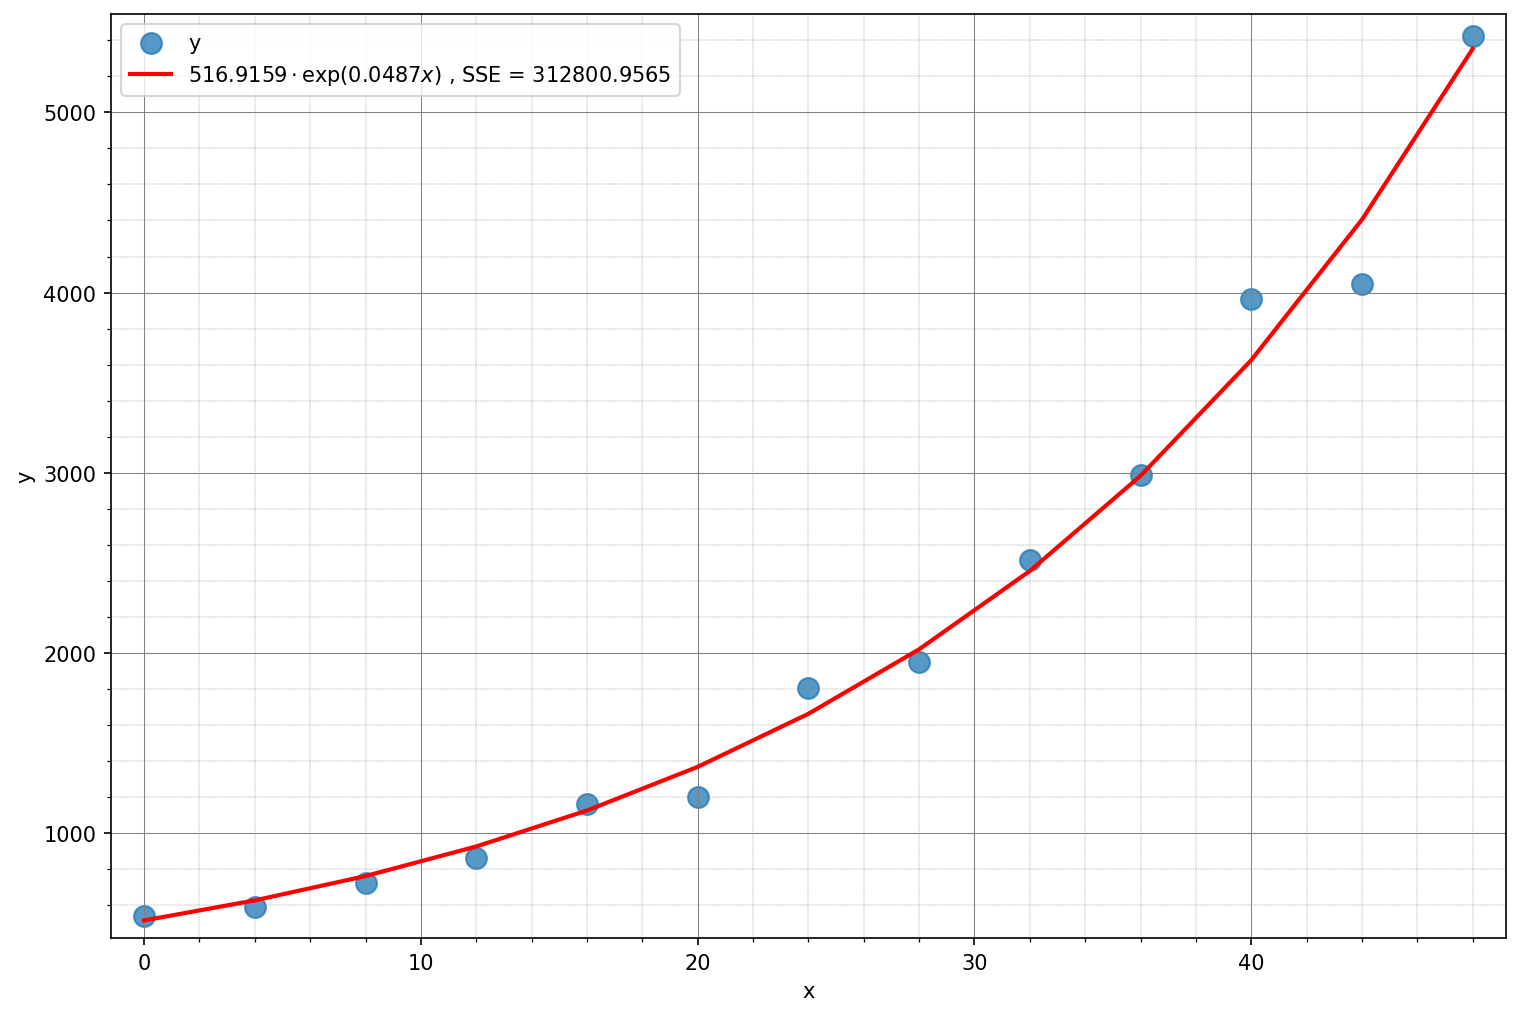

In [87]:
_ = plot_data(x, y, y_hat=y_hat, a=a_exp, b=b_exp, sse=sse, model_for_legend="exp")

# Part 4 - An alternative way to fit a model

The `scipy.optimize` package offers an alternative function that is a higher-level approach to model fitting: `curve_fit()`. This function still uses optimization behind the curtains but does most of the work for us.

Please notice, that it is important to have the independent value `x` as the first argument of the model to fit. This has been our convention all along (also for the optimization sections), so nothing changes for us.

In [88]:
def exponential_model(x, a, b):
    """Exponential model y_hat = a * exp(b * x)."""
    y_hat = a * np.exp(b * x)
    return y_hat

Let's try fitting a curve to our `y` vector above. Please notice that `curve_fit` is very sensitive to the initial values of the parameters!

In [89]:
start = (y[0], 0.5)
popt, _ = optimize.curve_fit(exponential_model, x, y, p0 = start)

a = popt[0]
b = popt[1]

We can use the estimated parameters to calculate the predicted `y_hat` and the `sse`.

In [90]:
y_hat = exponential_model(x, popt[0], popt[1])
sse = calc_sse(y, y_hat)

Let's plot and compare the results.

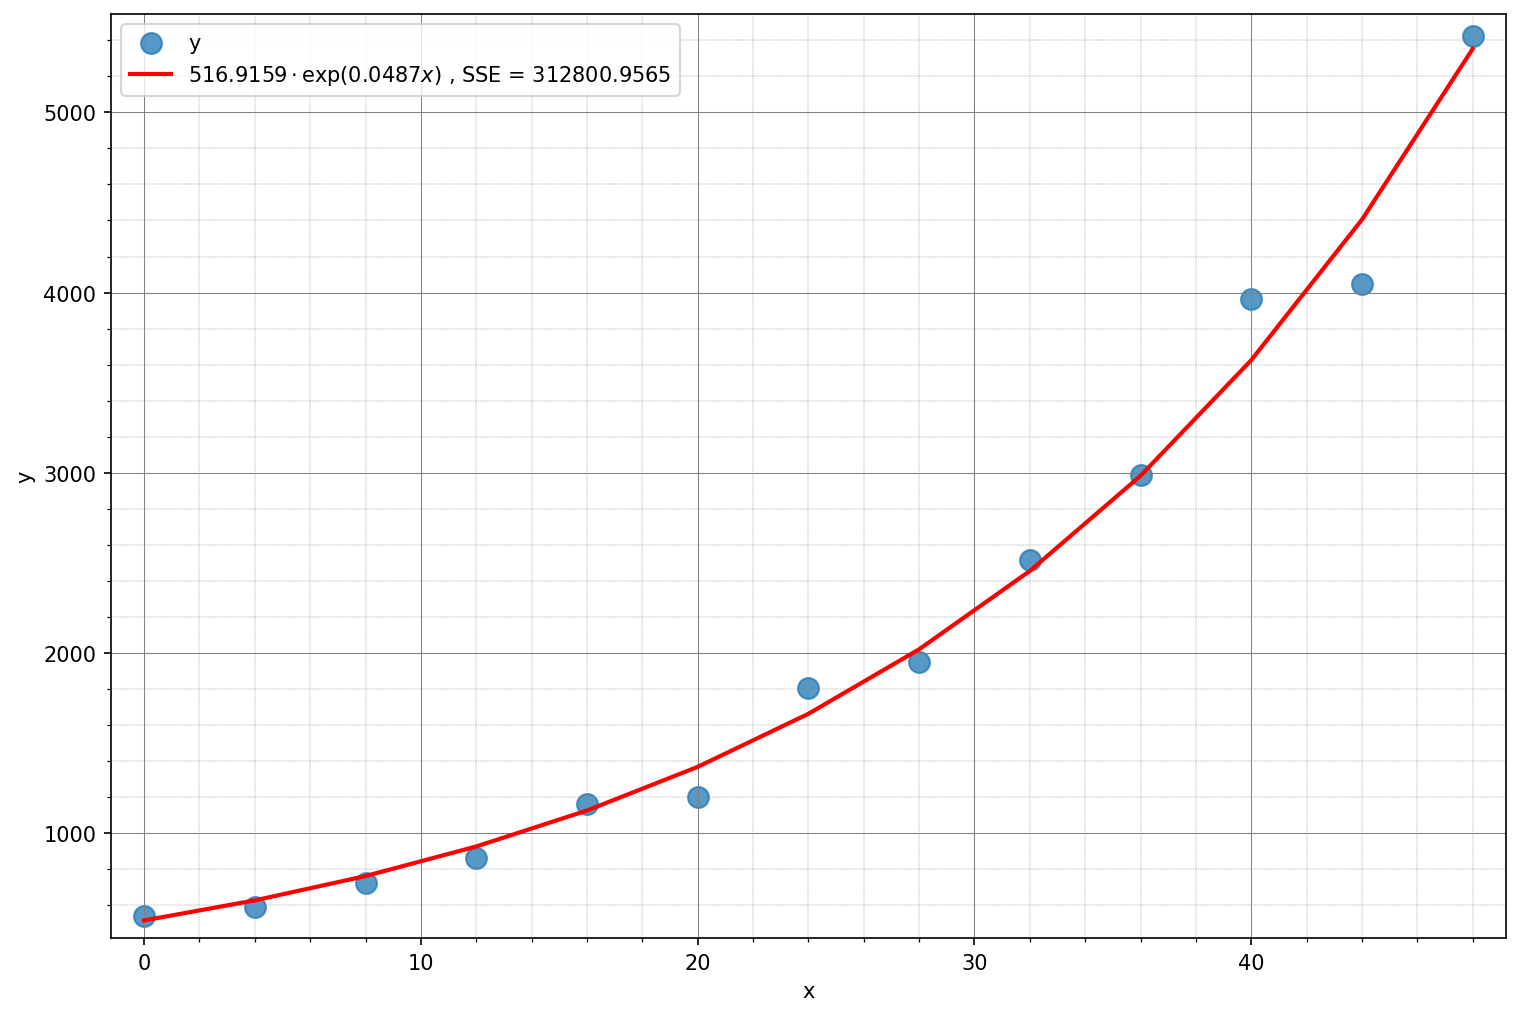

In [91]:
_ = plot_data(x, y, y_hat=y_hat, a=popt[0], b=popt[1], sse=sse, model_for_legend="exp")

We obtain the same fit as with out optimization from the previous section.

## Weighed curve fitting

Le't recreate the same dataset with replicates of various quality that we analyzed earlier.

In [92]:
# We reset the random number generator so that we can recreate the same dataset as earlier
rng = np.random.RandomState(1)

In [93]:
nReps       = 5   # Number of repeated (independent) measurements y.
w0          = 3.0 # Noise level on the repeated measurement example.
w1          = 0.5 # Weight that scales the standard deviation of the noise for the first half of the data.
w2          = 5.0 # Weight that scales the standard deviation of the noise for the second half of the data.
data_offset = 5.0 # Amount by which the second half of the data is moved away from the ideal fit.

x = np.linspace(start=0, stop=20, num=21)

n1 = len(x) // 2
n2 = len(x) - n1

yy = np.zeros((nReps, len(x)))
for i in range(nReps):
    noise = np.zeros(len(x))
    noise[:n1] = w1 * rng.randn(n1)
    noise[n1:] = data_offset + w2 * rng.randn(n2)
    yy[i, :] = a_real * x + b_real + w0 * noise

yy.shape

(5, 21)

Calculate yy_mean:

In [94]:
yy_mean = yy.mean(axis = 0)

Let's calculate the standard errors.

In [95]:
# Calculate the standard error of the mean (per point)
sd = yy.std(axis = 0, ddof = 1)
se = sd / np.sqrt(nReps)

Let's redefine our linear model:

In [96]:
def linear_model(x, a, b):
    """Our linear model y = a * x + b."""
    y_hat = a * x + b
    return y_hat

Now use `curve_fit()` with the weights to fit the line.

In [97]:
start = (0.0, 0.0)
popt, pcov = optimize.curve_fit(linear_model, x, yy_mean, p0 = start, sigma=se)

We get the parameters:

In [98]:
a_fit_weighed = popt[0]
b_fit_weighed = popt[1]

We can calculate the predicted values and the SSE.

In [99]:
y_hat = linear_model(x, a_fit_weighed, b_fit_weighed)
sse = calc_sse(yy_mean, y_hat)

And plot the result:

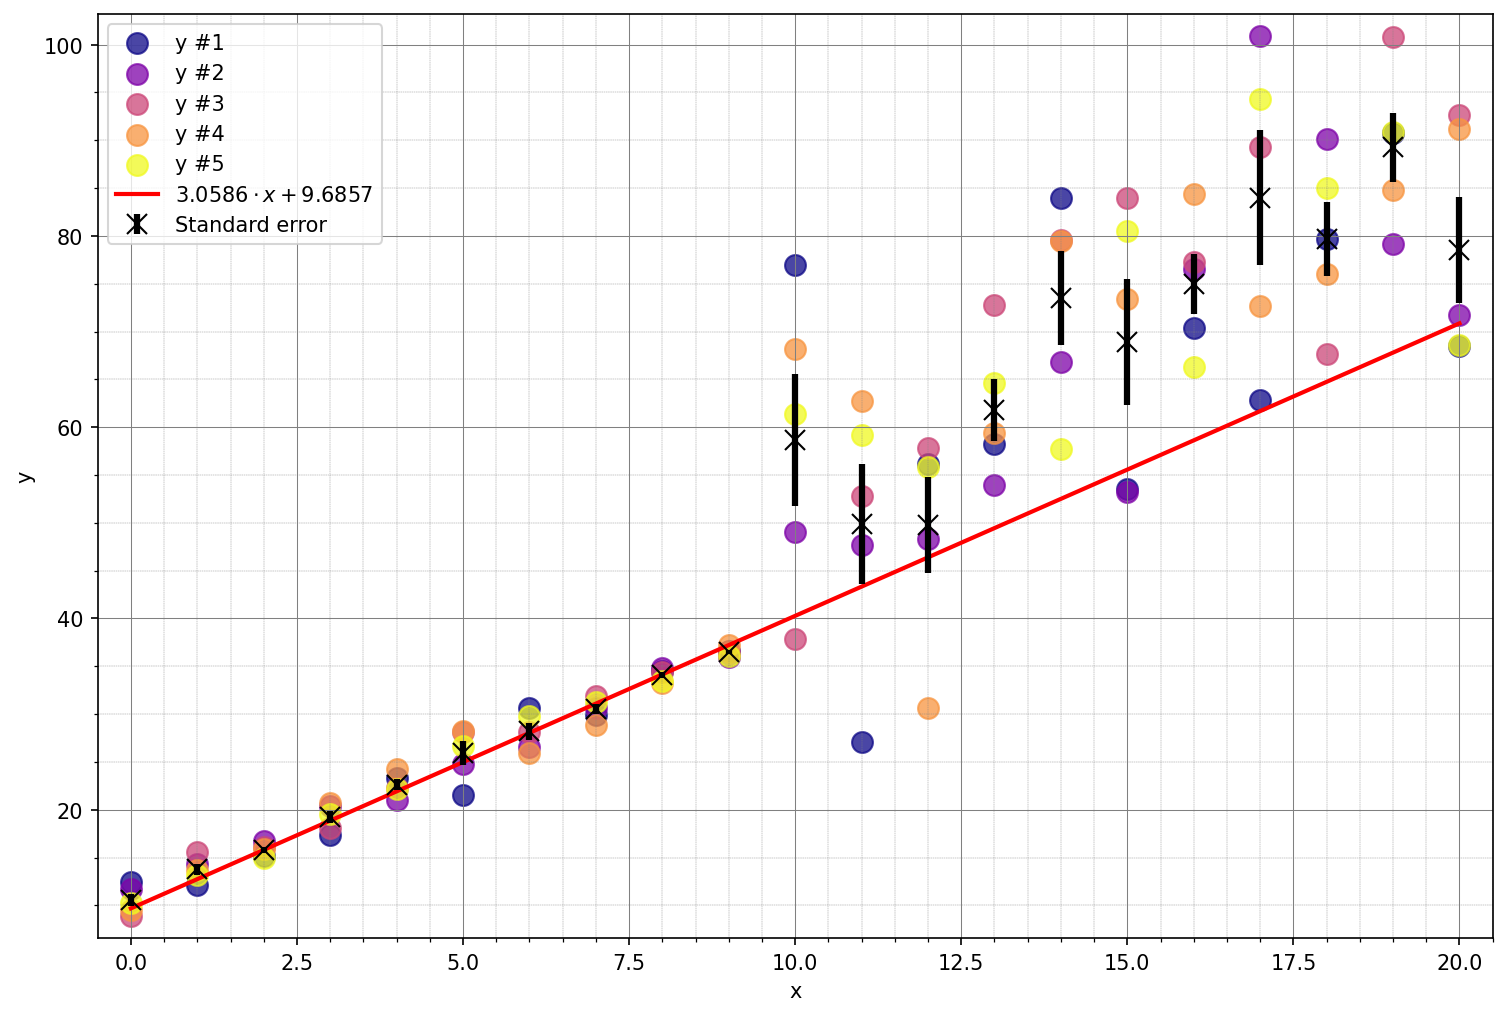

In [100]:
_ = plot_data(x, yy, x2=x, y_hat=y_hat, a=a_fit_weighed, b=b_fit_weighed, errors=se, errors_label="Standard error")

We obtain the same result as earlier.